In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

# Statistics
from scipy.interpolate import interp1d

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score
)

# Models
from catboost import (
    CatBoostRegressor,
    CatBoostClassifier
)

from lightgbm import (
    LGBMRegressor,
    LGBMClassifier
)

# Display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# Style
sns.set_style("whitegrid")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ============================================================
# LOAD DESIGN & REALIZATION DATA
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# File Path
# ------------------------------------------------------------

file = "SATURATION_041944.xlsx"

# ------------------------------------------------------------
# Read Excel Sheets
# ------------------------------------------------------------

design_raw = pd.read_excel(
    file,
    sheet_name="DESIGN",
    header=None
)

fwct_raw = pd.read_excel(
    file,
    sheet_name="FWCT",
    header=None
)

fwct2_raw = pd.read_excel(
    file,
    sheet_name="FWCT2",
    header=None
)

fwpt_raw = pd.read_excel(
    file,
    sheet_name="FWPT",
    header=None
)

fwpt2_raw = pd.read_excel(
    file,
    sheet_name="FWPT2",
    header=None
)

# ------------------------------------------------------------
# Display Basic Information
# ------------------------------------------------------------

print("=" * 80)
print("DESIGN SHEET")
print("=" * 80)

print("Shape:", design_raw.shape)

display(design_raw.head())

print()

print("=" * 80)
print("FWCT")
print("=" * 80)

print("Shape:", fwct_raw.shape)

print("=" * 80)
print("FWCT RUN 2")
print("=" * 80)

print("Shape:", fwct2_raw.shape)

display(fwct2_raw.head())

print()

print("=" * 80)
print("FWPT")
print("=" * 80)

print("Shape:", fwpt_raw.shape)

display(fwpt_raw.head())

print("=" * 80)
print("FWPT RUN 2")
print("=" * 80)

print("Shape:", fwpt2_raw.shape)

display(fwpt2_raw.head())

DESIGN SHEET
Shape: (6, 6)


,0,1,2,3,4,5
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,RUNS,PERMX,PERMZ,RELPERM
2,NaN,NaN,1,0.9,1.1,1.1
3,NaN,NaN,2,0.9,0.9,0.9
4,NaN,NaN,3,1.1,1.1,0.9



FWCT
Shape: (194, 10)
FWCT RUN 2
Shape: (193, 8)


,0,1,2,3,4,5,6,7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,TIME,FWCT R1R2',FWCT R2R2',FWCT R3R2',FWCT R4R2',FWCTH OBSERVED
2,NaN,NaN,(YEARS),NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,0,0,0,0,0,0
4,NaN,NaN,0.084932,0,0,0,0,0.000885



FWPT
Shape: (194, 9)


,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,R1R1,R2R1,R3R1,R4R1,OBSERVED
2,NaN,NaN,NaN,YEARS,FWPT,FWPT,FWPT,FWPT,FWPTH
3,NaN,NaN,NaN,(YEARS),(STB),(STB),(STB),(STB),(STB)
4,NaN,NaN,NaN,0,0,0,0,0,0


FWPT RUN 2
Shape: (194, 9)


,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,TIME,FWPT R1R2,FWPT R2R2,FWPT R3R2,FWPT R4R2,FWPTH OBSERVED
3,NaN,NaN,NaN,(YEARS),(STB),(STB),(STB),(STB),(STB)
4,NaN,NaN,NaN,0,0,0,0,0,0


In [3]:
# ============================================================
# EXTRACT DESIGN TABLE
# ============================================================

design = pd.DataFrame({

    "RUNS": design_raw.iloc[2:, 2].values,

    "PERMX": design_raw.iloc[2:, 3].values,

    "PERMZ": design_raw.iloc[2:, 4].values,

    "RELPERM": design_raw.iloc[2:, 5].values,

})

# ------------------------------------------------------------
# Remove Empty Rows
# ------------------------------------------------------------

design = (
    design
    .dropna(how="all")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Convert Numeric Columns
# ------------------------------------------------------------

for col in design.columns[1:]:

    design[col] = pd.to_numeric(
        design[col],
        errors="coerce"
    )

print("=" * 80)
print("DESIGN TABLE")
print("=" * 80)

print("Shape:", design.shape)

display(design)

print("\nMissing Values")

display(design.isnull().sum())

DESIGN TABLE
Shape: (4, 4)


,RUNS,PERMX,PERMZ,RELPERM
0,1,0.9,1.1,1.1
1,2,0.9,0.9,0.9
2,3,1.1,1.1,0.9
3,4,1.1,0.9,1.1



Missing Values


RUNS       0
PERMX      0
PERMZ      0
RELPERM    0
dtype: int64

In [4]:
print(design["RUNS"].unique())

[1 2 3 4]


In [5]:
# ============================================================
# EXTRACT REALIZATION TABLE
# ============================================================

realizations = pd.DataFrame({

    "SIM_Year": fwct_raw.iloc[4:,2].values,

    "FWCT R1R1": fwct_raw.iloc[4:,3].values,

    "FWCT R2R1": fwct_raw.iloc[4:,4].values,

    "FWCT R3R1": fwct_raw.iloc[4:,5].values,

    "FWCT R4R1": fwct_raw.iloc[4:,6].values,

    "FWCT R1R2": fwct2_raw.iloc[3:,3].values,

    "FWCT R2R2": fwct2_raw.iloc[3:,4].values,

    "FWCT R3R2": fwct2_raw.iloc[3:,5].values,

    "FWCT R4R2": fwct2_raw.iloc[3:,5].values,

    "FWPT R1R1": fwpt_raw.iloc[4:,4].values,

    "FWPT R2R1": fwpt_raw.iloc[4:,5].values,

    "FWPT R3R1": fwpt_raw.iloc[4:,6].values,

    "FWPT R4R1": fwpt_raw.iloc[4:,7].values,

    "FWPT R1R2": fwpt2_raw.iloc[4:,4].values,
    
    "FWPT R2R2": fwpt2_raw.iloc[4:,5].values,
    
    "FWPT R3R2": fwpt2_raw.iloc[4:,6].values,
    
    "FWPT R4R2": fwpt2_raw.iloc[4:,7].values,

    "FWPTH OBS": fwpt_raw.iloc[4:,8].values,

    "FWPTH_R2 OBS": fwpt2_raw.iloc[4:,8].values,
    
    "FWCT OBS": fwct_raw.iloc[4:,9].values,

    "FWCT_R2 OBS": fwct2_raw.iloc[3:,7].values,
})

# ------------------------------------------------------------
# Convert Everything to Numeric
# ------------------------------------------------------------

for col in realizations.columns:

    realizations[col] = pd.to_numeric(
        realizations[col],
        errors="coerce"
    )

# ------------------------------------------------------------
# Remove Rows Without Simulation Time
# ------------------------------------------------------------

realizations = (
    realizations
    .dropna(subset=["SIM_Year"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Remove Original Observation Columns
# ------------------------------------------------------------

print("=" * 80)
print("REALIZATION TABLE")
print("=" * 80)

print("Shape:", realizations.shape)

display(realizations.head())

print("\nMissing Values")

display(realizations.isnull().sum())

REALIZATION TABLE
Shape: (190, 21)


,SIM_Year,FWCT R1R1,FWCT R2R1,FWCT R3R1,FWCT R4R1,FWCT R1R2,FWCT R2R2,FWCT R3R2,FWCT R4R2,FWPT R1R1,FWPT R2R1,FWPT R3R1,FWPT R4R1,FWPT R1R2,FWPT R2R2,FWPT R3R2,FWPT R4R2,FWPTH OBS,FWPTH_R2 OBS,FWCT OBS,FWCT_R2 OBS
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
1,0.084932,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,267.06500,267.06500,0.000885,0.000885
2,0.167123,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,565.53503,565.53503,0.000469,0.000469
3,0.252055,0.000006,0.000004,0.000003,0.000005,0.00001,0.000005,0.000004,0.000004,0.646922,0.319242,0.275281,0.485294,1.386499,0.478541,0.373314,1.033188,580.22900,580.22900,0.000033,0.000033
4,0.334247,0.000049,0.000040,0.000037,0.000048,0.00007,0.000047,0.000041,0.000041,13.169907,11.246421,10.222940,12.718828,18.200674,12.582749,11.264229,17.426624,586.82898,586.82898,0.000015,0.000015



Missing Values


SIM_Year        0
FWCT R1R1       0
FWCT R2R1       0
FWCT R3R1       0
FWCT R4R1       0
FWCT R1R2       0
FWCT R2R2       0
FWCT R3R2       0
FWCT R4R2       0
FWPT R1R1       0
FWPT R2R1       0
FWPT R3R1       0
FWPT R4R1       0
FWPT R1R2       0
FWPT R2R2       0
FWPT R3R2       0
FWPT R4R2       0
FWPTH OBS       0
FWPTH_R2 OBS    0
FWCT OBS        0
FWCT_R2 OBS     0
dtype: int64

In [6]:
# ============================================================
# SAVE REALIZATIONS DATA TO EXCEL
# ============================================================

# Save to a new Excel file
realizations.to_excel(
    "saturation_output.xlsx",   # filename
    sheet_name="REALIZATIONS",    # sheet name
    index=False                   # don’t include row index
)

print("Realizations data saved to Realizations_Output.xlsx")


Realizations data saved to Realizations_Output.xlsx


In [7]:
# ============================================================
# CREATE PHYSICS-BASED MACHINE LEARNING DATASET
# ============================================================

import re

ml_data = []

# ------------------------------------------------------------
# Loop through every simulation column
# ------------------------------------------------------------

simulation_columns = [
    c for c in realizations.columns
    if c.startswith("FWCT R")
]

for fwct_col in simulation_columns:

    match = re.search(r"FWCT (R\d)(R\d)", fwct_col)

    if match is None:
        continue

    # --------------------------------------------------------
    # Extract Run and Rock
    # --------------------------------------------------------

    run_label = match.group(1)         
    rock = match.group(2)              

    run = int(run_label.replace("R", ""))  

    fwpt_col = f"FWPT {run_label}{rock}"

    # --------------------------------------------------------
    # Observation columns
    # --------------------------------------------------------

    if rock == "R1":
        obs_fwct = "FWCT OBS"
        obs_fwpt = "FWPTH OBS"
        rock_name = "Rock1"
    else:
        obs_fwct = "FWCT_R2 OBS"
        obs_fwpt = "FWPTH_R2 OBS"
        rock_name = "Rock2"

    # --------------------------------------------------------
    # Get design parameters
    # --------------------------------------------------------

    params_match = design.loc[
        design["RUNS"] == run
    ]

    if params_match.empty:
        print(f"Run {run} not found in design table...Skipped")
        continue

    params = params_match.iloc[0]

    # --------------------------------------------------------
    # Create dataframe
    # --------------------------------------------------------

    temp = pd.DataFrame({

        "Year": realizations["SIM_Year"],

        "Run": run_label,

        "Rock": rock_name,

        "PERMX": params["PERMX"],

        "PERMZ": params["PERMZ"],

        "RELPERM": params["RELPERM"],

        "Observed_FWCT": realizations[obs_fwct],

        "Simulated_FWCT": realizations[fwct_col],

        "Observed_FWPT": realizations[obs_fwpt],

        "Simulated_FWPT": realizations[fwpt_col]

    })

    # --------------------------------------------------------
    # Remove missing values
    # --------------------------------------------------------

    temp = (
        temp
        .dropna()
        .sort_values("Year")
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Physics Features
    # --------------------------------------------------------

    temp["FWCT_Error"] = (
        temp["Observed_FWCT"]
        - temp["Simulated_FWCT"]
    )

    temp["FWPT_Error"] = (
        temp["Observed_FWPT"]
        - temp["Simulated_FWPT"]
    )

    temp["Abs_FWCT_Error"] = (
        temp["FWCT_Error"].abs()
    )

    temp["Abs_FWPT_Error"] = (
        temp["FWPT_Error"].abs()
    )

    temp["Squared_FWCT_Error"] = (
        temp["FWCT_Error"] ** 2
    )

    temp["Squared_FWPT_Error"] = (
        temp["FWPT_Error"] ** 2
    )

    temp["Relative_FWCT_Error"] = np.where(
        temp["Observed_FWCT"] != 0,
        temp["Abs_FWCT_Error"] / temp["Observed_FWCT"],
        0
    )

    temp["Relative_FWPT_Error"] = np.where(
        temp["Observed_FWPT"] != 0,
        temp["Abs_FWPT_Error"] / temp["Observed_FWPT"],
        0
    )

    # --------------------------------------------------------
    # Time derivatives
    # --------------------------------------------------------

    temp["dFWCTdt_Observed"] = np.gradient(
        temp["Observed_FWCT"]
    )

    temp["dFWCTdt_Simulated"] = np.gradient(
        temp["Simulated_FWCT"]
    )

    temp["dFWPTdt_Observed"] = np.gradient(
        temp["Observed_FWPT"]
    )

    temp["dFWPTdt_Simulated"] = np.gradient(
        temp["Simulated_FWPT"]
    )

    temp["FWCT_Trend_Error"] = (
        temp["dFWCTdt_Observed"]
        - temp["dFWCTdt_Simulated"]
    )

    temp["FWPT_Trend_Error"] = (
        temp["dFWPTdt_Observed"]
        - temp["dFWPTdt_Simulated"]
    )

    ml_data.append(temp)

# ------------------------------------------------------------
# Merge all realizations
# ------------------------------------------------------------

ml_df = (
    pd.concat(
        ml_data,
        ignore_index=True
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("PHYSICS-BASED MACHINE LEARNING DATASET")
print("=" * 80)

print("Shape:", ml_df.shape)

display(ml_df.head())

print("\nRuns")

display(
    ml_df["Run"].value_counts().sort_index()
)

print("\nRock")

display(
    ml_df["Rock"].value_counts()
)

print("\nMissing Values")

display(
    ml_df.isnull().sum()
)

PHYSICS-BASED MACHINE LEARNING DATASET
Shape: (1520, 24)


,Year,Run,Rock,PERMX,PERMZ,RELPERM,Observed_FWCT,Simulated_FWCT,Observed_FWPT,Simulated_FWPT,FWCT_Error,FWPT_Error,Abs_FWCT_Error,Abs_FWPT_Error,Squared_FWCT_Error,Squared_FWPT_Error,Relative_FWCT_Error,Relative_FWPT_Error,dFWCTdt_Observed,dFWCTdt_Simulated,dFWPTdt_Observed,dFWPTdt_Simulated,FWCT_Trend_Error,FWPT_Trend_Error
0,0.000000,R1,Rock1,0.9,1.1,1.1,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,8.852344e-04,0.000000,267.065000,0.000000,0.000885,267.065000
1,0.084932,R1,Rock1,0.9,1.1,1.1,0.000885,0.000000,267.06500,0.000000,0.000885,267.065000,0.000885,267.065000,7.836400e-07,71323.714225,1.000000,1.000000,2.343483e-04,0.000000,282.767515,0.000000,0.000234,282.767515
2,0.167123,R1,Rock1,0.9,1.1,1.1,0.000469,0.000000,565.53503,0.000000,0.000469,565.535030,0.000469,565.535030,2.196766e-07,319829.870157,1.000000,1.000000,-4.261357e-04,0.000003,156.582000,0.323461,-0.000429,156.258539
3,0.252055,R1,Rock1,0.9,1.1,1.1,0.000033,0.000006,580.22900,0.646922,0.000027,579.582078,0.000027,579.582078,7.243695e-10,335915.385498,0.816495,0.998885,-2.266885e-04,0.000024,10.646975,6.584954,-0.000251,4.062021
4,0.334247,R1,Rock1,0.9,1.1,1.1,0.000015,0.000049,586.82898,13.169907,-0.000033,573.659073,0.000033,573.659073,1.118234e-09,329084.732035,2.182820,0.977558,8.508065e-07,0.000124,12.104005,48.463755,-0.000123,-36.359750



Runs


Run
R1    380
R2    380
R3    380
R4    380
Name: count, dtype: int64


Rock


Rock
Rock1    760
Rock2    760
Name: count, dtype: int64


Missing Values


Year                   0
Run                    0
Rock                   0
PERMX                  0
PERMZ                  0
RELPERM                0
Observed_FWCT          0
Simulated_FWCT         0
Observed_FWPT          0
Simulated_FWPT         0
FWCT_Error             0
FWPT_Error             0
Abs_FWCT_Error         0
Abs_FWPT_Error         0
Squared_FWCT_Error     0
Squared_FWPT_Error     0
Relative_FWCT_Error    0
Relative_FWPT_Error    0
dFWCTdt_Observed       0
dFWCTdt_Simulated      0
dFWPTdt_Observed       0
dFWPTdt_Simulated      0
FWCT_Trend_Error       0
FWPT_Trend_Error       0
dtype: int64

In [8]:
ml_df.tail()

,Year,Run,Rock,PERMX,PERMZ,RELPERM,Observed_FWCT,Simulated_FWCT,Observed_FWPT,Simulated_FWPT,FWCT_Error,FWPT_Error,Abs_FWCT_Error,Abs_FWPT_Error,Squared_FWCT_Error,Squared_FWPT_Error,Relative_FWCT_Error,Relative_FWPT_Error,dFWCTdt_Observed,dFWCTdt_Simulated,dFWPTdt_Observed,dFWPTdt_Simulated,FWCT_Trend_Error,FWPT_Trend_Error
1367,15.430137,R4,Rock2,1.1,0.9,1.1,0.773831,0.778438,56024772.0,74013568.0,-0.004607,-17988796.0,0.004607,17988796.0,0.000021,3.235968e+14,0.005953,0.321086,-0.009491,-0.009235,467908.0,556808.0,-0.000256,-88900.0
1368,15.515068,R4,Rock2,1.1,0.9,1.1,0.783712,0.803409,56434964.0,74504904.0,-0.019697,-18069940.0,0.019697,18069940.0,0.000388,3.265227e+14,0.025133,0.320191,-0.003354,0.015775,369046.0,475064.0,-0.019129,-106018.0
1369,15.597260,R4,Rock2,1.1,0.9,1.1,0.767123,0.809988,56762864.0,74963696.0,-0.042865,-18200832.0,0.042865,18200832.0,0.001837,3.312703e+14,0.055878,0.320647,0.008912,0.007461,352904.0,455108.0,0.001451,-102204.0
1370,15.682192,R4,Rock2,1.1,0.9,1.1,0.801536,0.818331,57140772.0,75415120.0,-0.016796,-18274348.0,0.016796,18274348.0,0.000282,3.339518e+14,0.020954,0.319813,0.029132,0.001177,387836.0,417492.0,0.027956,-29656.0
1371,15.764384,R4,Rock2,1.1,0.9,1.1,0.825388,0.812341,57538536.0,75798680.0,0.013046,-18260144.0,0.013046,18260144.0,0.000170,3.334329e+14,0.015806,0.317355,0.023852,-0.005990,397764.0,383560.0,0.029842,14204.0


In [8]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("=" * 80)
print("ML DATASET OVERVIEW")
print("=" * 80)

print(f"Shape: {ml_df.shape}")

print("\nColumns")

display(ml_df.columns)

print("\nData Types")

display(ml_df.dtypes)

print("\nSummary Statistics")

display(ml_df.describe())

print("\nMissing Values")

display(ml_df.isnull().sum())

# ============================================================
# RUNS AND ROCK DISTRIBUTION
# ============================================================

print("=" * 80)
print("RUN DISTRIBUTION")
print("=" * 80)

display(
    ml_df["Run"].value_counts().sort_index()
)

print()

print("=" * 80)
print("ROCK DISTRIBUTION")
print("=" * 80)

display(
    ml_df["Rock"].value_counts()
)

print()

print("=" * 80)
print("RUN VS ROCK")
print("=" * 80)

display(
    pd.crosstab(
        ml_df["Run"],
        ml_df["Rock"]
    )
)

# ============================================================
# NUMERICAL FEATURES
# ============================================================

numeric_cols = ml_df.select_dtypes(include="number")

display(
    numeric_cols.describe().T
)

ML DATASET OVERVIEW
Shape: (1520, 24)

Columns


Index(['Year', 'Run', 'Rock', 'PERMX', 'PERMZ', 'RELPERM', 'Observed_FWCT',
       'Simulated_FWCT', 'Observed_FWPT', 'Simulated_FWPT', 'FWCT_Error',
       'FWPT_Error', 'Abs_FWCT_Error', 'Abs_FWPT_Error', 'Squared_FWCT_Error',
       'Squared_FWPT_Error', 'Relative_FWCT_Error', 'Relative_FWPT_Error',
       'dFWCTdt_Observed', 'dFWCTdt_Simulated', 'dFWPTdt_Observed',
       'dFWPTdt_Simulated', 'FWCT_Trend_Error', 'FWPT_Trend_Error'],
      dtype='object')


Data Types


Year                   float64
Run                     object
Rock                    object
PERMX                  float64
PERMZ                  float64
RELPERM                float64
Observed_FWCT          float64
Simulated_FWCT         float64
Observed_FWPT          float64
Simulated_FWPT         float64
FWCT_Error             float64
FWPT_Error             float64
Abs_FWCT_Error         float64
Abs_FWPT_Error         float64
Squared_FWCT_Error     float64
Squared_FWPT_Error     float64
Relative_FWCT_Error    float64
Relative_FWPT_Error    float64
dFWCTdt_Observed       float64
dFWCTdt_Simulated      float64
dFWPTdt_Observed       float64
dFWPTdt_Simulated      float64
FWCT_Trend_Error       float64
FWPT_Trend_Error       float64
dtype: object


Summary Statistics


...


ROCK DISTRIBUTION


Rock
Rock1    760
Rock2    760
Name: count, dtype: int64


RUN VS ROCK


Rock,Rock1,Rock2
Run,,
R1,190,190
R2,190,190
R3,190,190
R4,190,190


,count,mean,std,min,25%,50%,75%,max
Year,1520.0,7.883937e+00,4.575356e+00,0.000000e+00,3.926027e+00,7.886301e+00,1.184657e+01,1.576438e+01
PERMX,1520.0,1.000000e+00,1.000329e-01,9.000000e-01,9.000000e-01,1.000000e+00,1.100000e+00,1.100000e+00
PERMZ,1520.0,1.000000e+00,1.000329e-01,9.000000e-01,9.000000e-01,1.000000e+00,1.100000e+00,1.100000e+00
RELPERM,1520.0,1.000000e+00,1.000329e-01,9.000000e-01,9.000000e-01,1.000000e+00,1.100000e+00,1.100000e+00
Observed_FWCT,1520.0,4.376503e-01,2.814456e-01,0.000000e+00,1.538557e-01,5.057824e-01,6.782670e-01,8.389161e-01
Simulated_FWCT,1520.0,5.144455e-01,2.636115e-01,0.000000e+00,3.579425e-01,5.839005e-01,7.265515e-01,9.696822e-01
Observed_FWPT,1520.0,2.206015e+07,1.885991e+07,0.000000e+00,1.461786e+06,2.114657e+07,3.869554e+07,5.753854e+07
Simulated_FWPT,1520.0,3.158223e+07,2.555651e+07,0.000000e+00,5.432768e+06,2.846924e+07,5.590502e+07,8.157032e+07
FWCT_Error,1520.0,-7.679526e-02,1.310399e-01,-9.689396e-01,-1.168881e-01,-6.035287e-02,-5.259378e-04,1.022527e-01
FWPT_Error,1520.0,-9.522075e+06,7.342791e+06,-2.436031e+07,-1.568515e+07,-8.029308e+06,-3.160947e+06,5.799537e+02


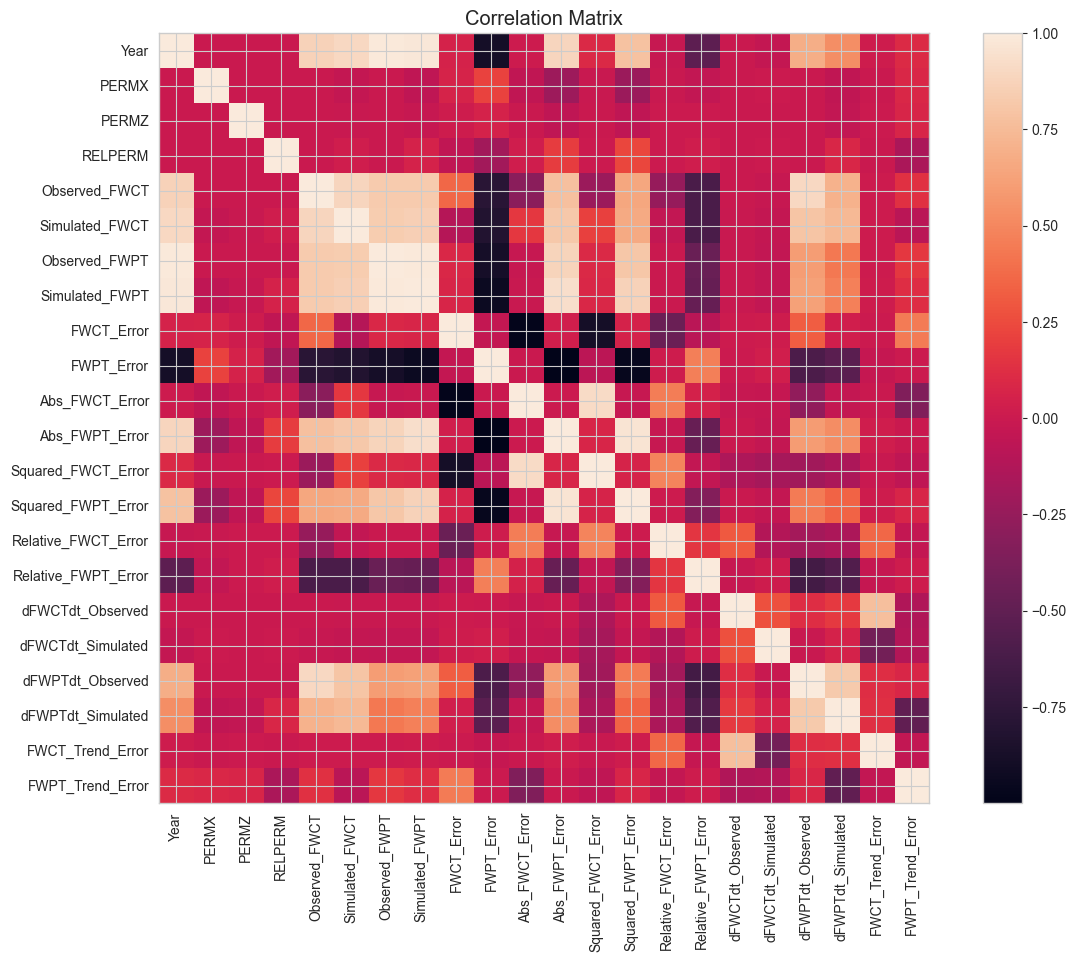

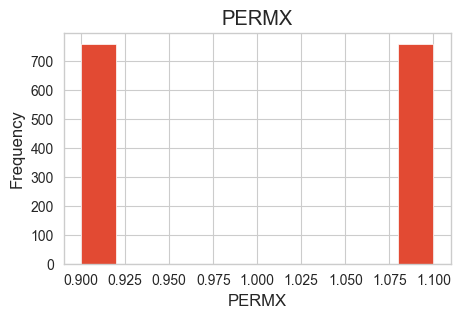

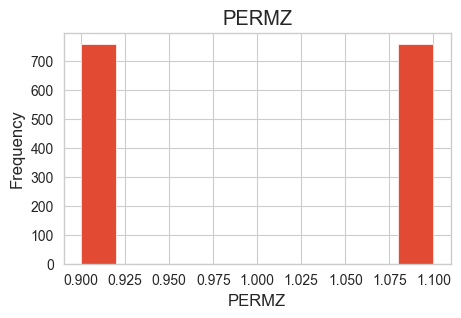

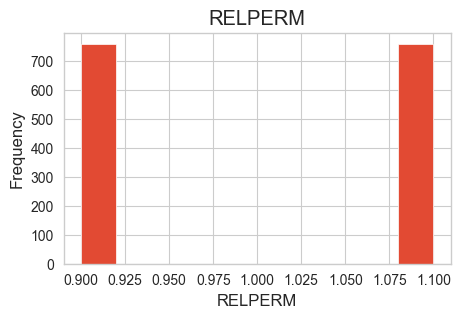

In [9]:
# ============================================================
# CORRELATION MATRIX
# ============================================================

import matplotlib.pyplot as plt

corr = numeric_cols.corr()

plt.figure(figsize=(14,10))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

# ============================================================
# DESIGN PARAMETERS
# ============================================================

parameters = [
    "PERMX",
    "PERMZ",
    "RELPERM"
]

for col in parameters:

    plt.figure(figsize=(5,3))

    plt.hist(
        ml_df[col],
        bins=10
    )

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

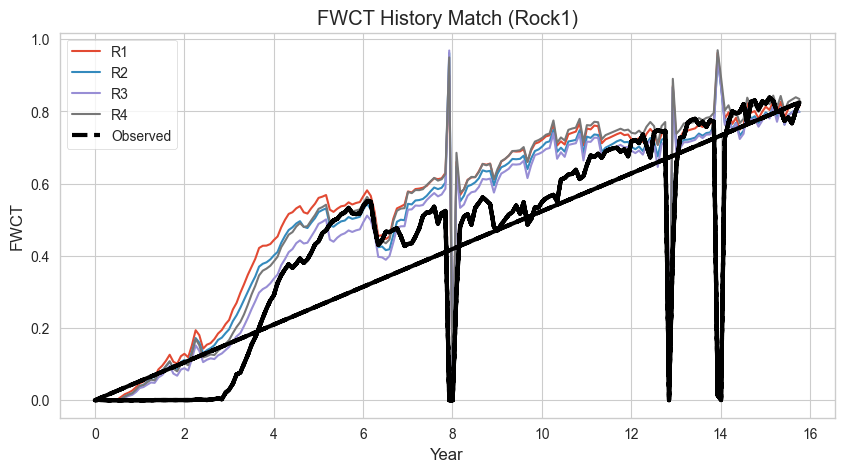

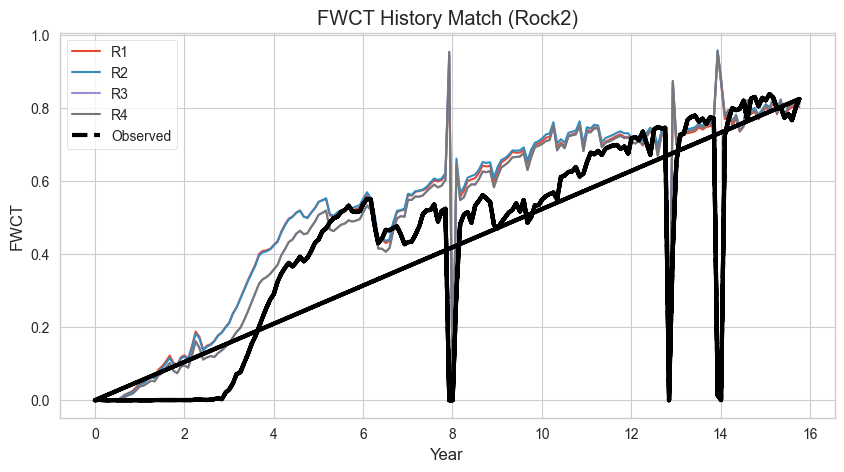

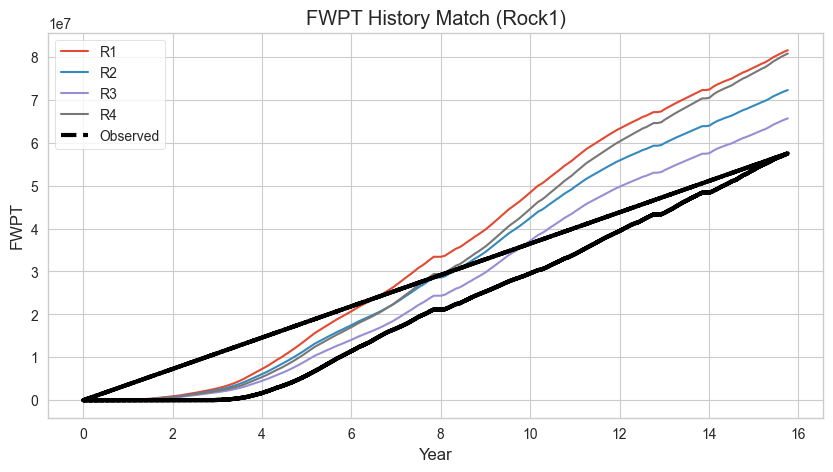

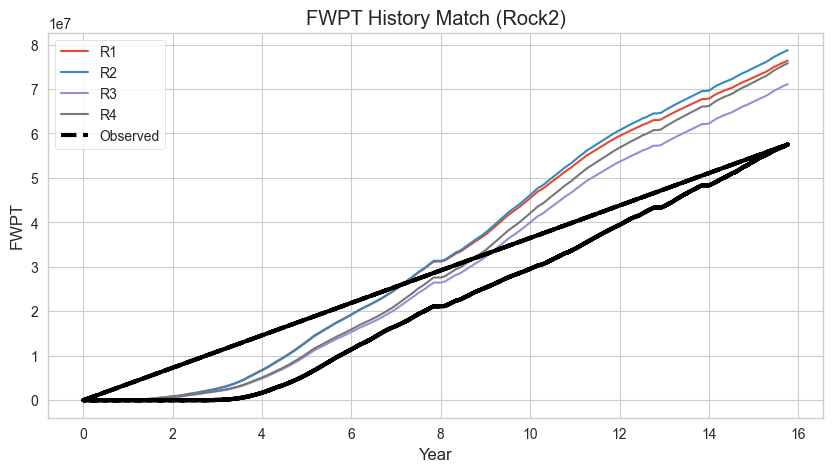

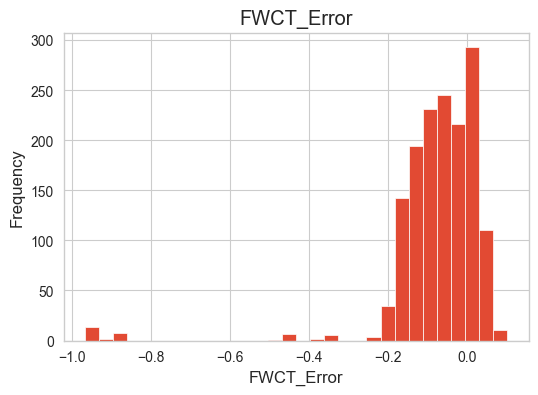

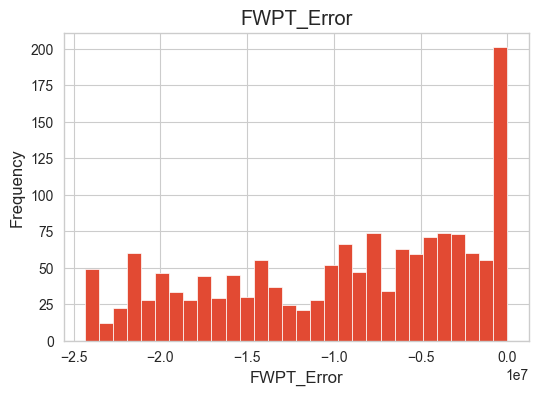

In [10]:
# ============================================================
# FWCT HISTORY MATCH
# ============================================================

for rock in ml_df["Rock"].unique():

    plt.figure(figsize=(10,5))

    rock_df = ml_df[
        ml_df["Rock"] == rock
    ]

    for run in sorted(rock_df["Run"].unique()):

        temp = rock_df[
            rock_df["Run"] == run
        ]

        plt.plot(
            temp["Year"],
            temp["Simulated_FWCT"],
            label=f"{run}"
        )

    plt.plot(
        rock_df["Year"],
        rock_df["Observed_FWCT"],
        "k--",
        linewidth=3,
        label="Observed"
    )

    plt.title(f"FWCT History Match ({rock})")

    plt.xlabel("Year")

    plt.ylabel("FWCT")

    plt.legend()

    plt.grid(True)

    plt.show()

# ============================================================
# FWPT HISTORY MATCH
# ============================================================

for rock in ml_df["Rock"].unique():

    plt.figure(figsize=(10,5))

    rock_df = ml_df[
        ml_df["Rock"] == rock
    ]

    for run in sorted(rock_df["Run"].unique()):

        temp = rock_df[
            rock_df["Run"] == run
        ]

        plt.plot(
            temp["Year"],
            temp["Simulated_FWPT"],
            label=f"{run}"
        )

    plt.plot(
        rock_df["Year"],
        rock_df["Observed_FWPT"],
        "k--",
        linewidth=3,
        label="Observed"
    )

    plt.title(f"FWPT History Match ({rock})")

    plt.xlabel("Year")

    plt.ylabel("FWPT")

    plt.legend()

    plt.grid(True)

    plt.show()

# ============================================================
# ERROR DISTRIBUTION
# ============================================================

errors = [
    "FWCT_Error",
    "FWPT_Error"
]

for col in errors:

    plt.figure(figsize=(6,4))

    plt.hist(
        ml_df[col],
        bins=30
    )

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

In [11]:
# ============================================================
# PREPARE FEATURES
# ============================================================

# Encode Rock as numeric
ml_df["Rock"] = (
    ml_df["Rock"]
    .map({
        "Rock1": 0,
        "Rock2": 1
    })
)

feature_columns = [

    "Year",

    "PERMX",

    "PERMZ",

    "RELPERM",

    "Rock"

]

X = ml_df[feature_columns]

# ============================================================
# TARGETS
# ============================================================

target_columns = [

    "Simulated_FWCT",

    "Simulated_FWPT"

]

y = ml_df[target_columns]

# ============================================================
# GROUPS
# ============================================================

groups = ml_df["Run"]

print("=" * 100)
print("DATA READY")
print("=" * 100)

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)
print("Groups        :", groups.nunique())

print("\nRealizations")

print(groups.unique())

# ============================================================
# LEAVE-ONE-GROUP-OUT CROSS VALIDATION
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()

print("=" * 100)
print("LOGO FOLDS")
print("=" * 100)

for fold, (train_idx, test_idx) in enumerate(

    logo.split(

        X,

        y,

        groups

    ),

    start=1

):

    train_runs = groups.iloc[train_idx].unique()

    test_runs = groups.iloc[test_idx].unique()

    print(f"\nFold {fold}")

    print("-" * 60)

    print("Validation Run :")

    print(test_runs)

    print()

    print("Training Runs :")

    print(train_runs)

    print()

    print("Training Samples :", len(train_idx))

    print("Validation Samples :", len(test_idx))

DATA READY
Feature Shape : (1520, 5)
Target Shape  : (1520, 2)
Groups        : 4

Realizations
['R1' 'R2' 'R3' 'R4']
LOGO FOLDS

Fold 1
------------------------------------------------------------
Validation Run :
['R1']

Training Runs :
['R2' 'R3' 'R4']

Training Samples : 1140
Validation Samples : 380

Fold 2
------------------------------------------------------------
Validation Run :
['R2']

Training Runs :
['R1' 'R3' 'R4']

Training Samples : 1140
Validation Samples : 380

Fold 3
------------------------------------------------------------
Validation Run :
['R3']

Training Runs :
['R1' 'R2' 'R4']

Training Samples : 1140
Validation Samples : 380

Fold 4
------------------------------------------------------------
Validation Run :
['R4']

Training Runs :
['R1' 'R2' 'R3']

Training Samples : 1140
Validation Samples : 380


In [12]:
# ============================================================
# VERIFY NO DATA LEAKAGE
# ============================================================

print("="*100)
print("CHECKING DATA LEAKAGE")
print("="*100)

for fold,(train_idx,test_idx) in enumerate(

    logo.split(

        X,

        y,

        groups

    ),

    start=1

):

    train_groups = set(

        groups.iloc[train_idx]

    )

    test_groups = set(

        groups.iloc[test_idx]

    )

    overlap = train_groups.intersection(

        test_groups

    )

    print(

        f"Fold {fold} :",

        "PASS" if len(overlap)==0 else "FAILED"

    )

CHECKING DATA LEAKAGE
Fold 1 : PASS
Fold 2 : PASS
Fold 3 : PASS
Fold 4 : PASS


In [13]:
# ============================================================
# PHASE 3
# PREPARE FORWARD SURROGATE DATASET
# ============================================================

# ------------------------------------------------------------
# Input Features
# ------------------------------------------------------------

feature_columns = [

    "PERMX",

    "PERMZ",

    "RELPERM",

    "Rock",

    "Year"

]

X = ml_df[feature_columns].copy()

# ------------------------------------------------------------
# Targets
# ------------------------------------------------------------

target_columns = [

    "Simulated_FWCT",

    "Simulated_FWPT"

]

y = ml_df[target_columns].copy()

print("=" * 100)
print("FORWARD SURROGATE DATASET")
print("=" * 100)

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

print("\nInput Features")

display(X.head())

print("\nTarget Variables")

display(y.head())

FORWARD SURROGATE DATASET
Feature Shape : (1520, 5)
Target Shape  : (1520, 2)

Input Features


,PERMX,PERMZ,RELPERM,Rock,Year
0,0.9,1.1,1.1,0,0.000000
1,0.9,1.1,1.1,0,0.084932
2,0.9,1.1,1.1,0,0.167123
3,0.9,1.1,1.1,0,0.252055
4,0.9,1.1,1.1,0,0.334247



Target Variables


,Simulated_FWCT,Simulated_FWPT
0,0.000000,0.000000
1,0.000000,0.000000
2,0.000000,0.000000
3,0.000006,0.646922
4,0.000049,13.169907


In [14]:
# ============================================================
# FORWARD SURROGATE MODEL
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

logo = LeaveOneGroupOut()

groups = ml_df["Run"]

# Store predictions for both outputs
predictions = np.zeros(y.shape)

fwct_rmse_scores = []
fwpt_rmse_scores = []

for fold, (train_idx, test_idx) in enumerate(

    logo.split(X, y, groups),

    start=1

):

    print("=" * 80)
    print(f"Fold {fold}")
    print("=" * 80)

    model = MultiOutputRegressor(

        CatBoostRegressor(

            iterations=1000,

            depth=8,

            learning_rate=0.03,

            loss_function="RMSE",

            random_seed=42,

            verbose=False

        )

    )

    model.fit(

        X.iloc[train_idx],

        y.iloc[train_idx]

    )

    pred = model.predict(

        X.iloc[test_idx]

    )

    predictions[test_idx] = pred

    # --------------------------------------------------------
    # Compute RMSE for each target
    # --------------------------------------------------------

    fwct_rmse = np.sqrt(

        mean_squared_error(

            y.iloc[test_idx]["Simulated_FWCT"],

            pred[:, 0]

        )

    )

    fwpt_rmse = np.sqrt(

        mean_squared_error(

            y.iloc[test_idx]["Simulated_FWPT"],

            pred[:, 1]

        )

    )

    fwct_rmse_scores.append(fwct_rmse)

    fwpt_rmse_scores.append(fwpt_rmse)

    print("Validation Run :", groups.iloc[test_idx].unique()[0])

    print("FWCT RMSE :", round(fwct_rmse, 6))

    print("FWPT RMSE :", round(fwpt_rmse, 3))

Fold 1
Validation Run : R1
FWCT RMSE : 0.082522
FWPT RMSE : 12997876.408
Fold 2
Validation Run : R2
FWCT RMSE : 0.108508
FWPT RMSE : 12416594.958
Fold 3
Validation Run : R3
FWCT RMSE : 0.115375
FWPT RMSE : 7545828.444
Fold 4
Validation Run : R4
FWCT RMSE : 0.115299
FWPT RMSE : 11798302.162


In [15]:
print(ml_df["Simulated_FWPT"].describe())

print()

print(ml_df["Observed_FWPT"].describe())

count    1.520000e+03
mean     3.158223e+07
std      2.555651e+07
min      0.000000e+00
25%      5.432768e+06
50%      2.846924e+07
75%      5.590502e+07
max      8.157032e+07
Name: Simulated_FWPT, dtype: float64

count    1.520000e+03
mean     2.206015e+07
std      1.885991e+07
min      0.000000e+00
25%      1.461786e+06
50%      2.114657e+07
75%      3.869554e+07
max      5.753854e+07
Name: Observed_FWPT, dtype: float64


In [16]:
# ============================================================
# FORWARD SURROGATE MODEL
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)
from catboost import CatBoostRegressor

logo = LeaveOneGroupOut()

groups = ml_df["Run"]

predictions = np.zeros(y.shape)

fwct_rmse_scores = []
fwpt_rmse_scores = []

fwct_nrmse_scores = []
fwpt_nrmse_scores = []

fwct_r2_scores = []
fwpt_r2_scores = []

# ------------------------------------------------------------
# Target ranges for NRMSE
# ------------------------------------------------------------

fwct_range = (
    y["Simulated_FWCT"].max()
    -
    y["Simulated_FWCT"].min()
)

fwpt_range = (
    y["Simulated_FWPT"].max()
    -
    y["Simulated_FWPT"].min()
)

for fold, (train_idx, test_idx) in enumerate(

    logo.split(X, y, groups),

    start=1

):

    print("=" * 80)
    print(f"Fold {fold}")
    print("=" * 80)

    model = MultiOutputRegressor(

        CatBoostRegressor(

            iterations=1000,

            depth=8,

            learning_rate=0.03,

            loss_function="RMSE",

            random_seed=42,

            verbose=False

        )

    )

    model.fit(

        X.iloc[train_idx],

        y.iloc[train_idx]

    )

    pred = model.predict(

        X.iloc[test_idx]

    )

    predictions[test_idx] = pred

    # --------------------------------------------------------
    # FWCT Metrics
    # --------------------------------------------------------

    fwct_rmse = np.sqrt(

        mean_squared_error(

            y.iloc[test_idx]["Simulated_FWCT"],

            pred[:, 0]

        )

    )

    fwct_nrmse = fwct_rmse / fwct_range

    fwct_r2 = r2_score(

        y.iloc[test_idx]["Simulated_FWCT"],

        pred[:, 0]

    )

    # --------------------------------------------------------
    # FWPT Metrics
    # --------------------------------------------------------

    fwpt_rmse = np.sqrt(

        mean_squared_error(

            y.iloc[test_idx]["Simulated_FWPT"],

            pred[:, 1]

        )

    )

    fwpt_nrmse = fwpt_rmse / fwpt_range

    fwpt_r2 = r2_score(

        y.iloc[test_idx]["Simulated_FWPT"],

        pred[:, 1]

    )

    # --------------------------------------------------------
    # Store Metrics
    # --------------------------------------------------------

    fwct_rmse_scores.append(fwct_rmse)
    fwpt_rmse_scores.append(fwpt_rmse)

    fwct_nrmse_scores.append(fwct_nrmse)
    fwpt_nrmse_scores.append(fwpt_nrmse)

    fwct_r2_scores.append(fwct_r2)
    fwpt_r2_scores.append(fwpt_r2)

    print("Validation Run :", groups.iloc[test_idx].unique()[0])

    print(f"FWCT RMSE  : {fwct_rmse:.6f}")
    print(f"FWCT NRMSE : {fwct_nrmse:.4f}")
    print(f"FWCT R²    : {fwct_r2:.4f}")

    print()

    print(f"FWPT RMSE  : {fwpt_rmse:,.2f}")
    print(f"FWPT NRMSE : {fwpt_nrmse:.4f}")
    print(f"FWPT R²    : {fwpt_r2:.4f}")

# ============================================================
# OVERALL PERFORMANCE
# ============================================================

print("\n" + "=" * 80)
print("OVERALL PERFORMANCE")
print("=" * 80)

print(f"Average FWCT RMSE  : {np.mean(fwct_rmse_scores):.6f}")
print(f"Average FWCT NRMSE : {np.mean(fwct_nrmse_scores):.4f}")
print(f"Average FWCT R²    : {np.mean(fwct_r2_scores):.4f}")

print()

print(f"Average FWPT RMSE  : {np.mean(fwpt_rmse_scores):,.2f}")
print(f"Average FWPT NRMSE : {np.mean(fwpt_nrmse_scores):.4f}")
print(f"Average FWPT R²    : {np.mean(fwpt_r2_scores):.4f}")


Fold 1
Validation Run : R1
FWCT RMSE  : 0.082522
FWCT NRMSE : 0.0851
FWCT R²    : 0.8976

FWPT RMSE  : 12,997,876.41
FWPT NRMSE : 0.1593
FWPT R²    : 0.7632
Fold 2
Validation Run : R2
FWCT RMSE  : 0.108508
FWCT NRMSE : 0.1119
FWCT R²    : 0.8254

FWPT RMSE  : 12,416,594.96
FWPT NRMSE : 0.1522
FWPT R²    : 0.7640
Fold 3
Validation Run : R3
FWCT RMSE  : 0.115375
FWCT NRMSE : 0.1190
FWCT R²    : 0.8102

FWPT RMSE  : 7,545,828.44
FWPT NRMSE : 0.0925
FWPT R²    : 0.8932
Fold 4
Validation Run : R4
FWCT RMSE  : 0.115299
FWCT NRMSE : 0.1189
FWCT R²    : 0.8184

FWPT RMSE  : 11,798,302.16
FWPT NRMSE : 0.1446
FWPT R²    : 0.7989

OVERALL PERFORMANCE
Average FWCT RMSE  : 0.105426
Average FWCT NRMSE : 0.1087
Average FWCT R²    : 0.8379

Average FWPT RMSE  : 11,189,650.49
Average FWPT NRMSE : 0.1372
Average FWPT R²    : 0.8048


In [18]:
# ============================================================
# FORWARD SURROGATE MODEL (LOG-TRANSFORMED FWPT)
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)
from catboost import CatBoostRegressor

# ------------------------------------------------------------
# Targets
# ------------------------------------------------------------

y = pd.DataFrame({

    "Simulated_FWCT": ml_df["Simulated_FWCT"],

    "Simulated_FWPT": np.log1p(
        ml_df["Simulated_FWPT"]
    )

})

logo = LeaveOneGroupOut()

groups = ml_df["Run"]

predictions = np.zeros((len(y), 2))

fwct_rmse_scores = []
fwpt_rmse_scores = []

fwct_nrmse_scores = []
fwpt_nrmse_scores = []

fwct_r2_scores = []
fwpt_r2_scores = []

# ------------------------------------------------------------
# Target ranges (Original Scale)
# ------------------------------------------------------------

fwct_range = (
    ml_df["Simulated_FWCT"].max()
    -
    ml_df["Simulated_FWCT"].min()
)

fwpt_range = (
    ml_df["Simulated_FWPT"].max()
    -
    ml_df["Simulated_FWPT"].min()
)

for fold, (train_idx, test_idx) in enumerate(

    logo.split(X, y, groups),

    start=1

):

    print("=" * 80)
    print(f"Fold {fold}")
    print("=" * 80)

    model = MultiOutputRegressor(

        CatBoostRegressor(

            iterations=1000,

            depth=8,

            learning_rate=0.03,

            loss_function="RMSE",

            random_seed=42,

            verbose=False

        )

    )

    model.fit(

        X.iloc[train_idx],

        y.iloc[train_idx]

    )

    pred = model.predict(

        X.iloc[test_idx]

    )

    # --------------------------------------------------------
    # Convert FWPT back to original scale
    # --------------------------------------------------------

    pred[:, 1] = np.expm1(pred[:, 1])

    predictions[test_idx] = pred

    # --------------------------------------------------------
    # FWCT Metrics
    # --------------------------------------------------------

    actual_fwct = ml_df.iloc[test_idx]["Simulated_FWCT"]

    fwct_rmse = np.sqrt(

        mean_squared_error(

            actual_fwct,

            pred[:, 0]

        )

    )

    fwct_nrmse = fwct_rmse / fwct_range

    fwct_r2 = r2_score(

        actual_fwct,

        pred[:, 0]

    )

    # --------------------------------------------------------
    # FWPT Metrics
    # --------------------------------------------------------

    actual_fwpt = ml_df.iloc[test_idx]["Simulated_FWPT"]

    fwpt_rmse = np.sqrt(

        mean_squared_error(

            actual_fwpt,

            pred[:, 1]

        )

    )

    fwpt_nrmse = fwpt_rmse / fwpt_range

    fwpt_r2 = r2_score(

        actual_fwpt,

        pred[:, 1]

    )

    fwct_rmse_scores.append(fwct_rmse)
    fwpt_rmse_scores.append(fwpt_rmse)

    fwct_nrmse_scores.append(fwct_nrmse)
    fwpt_nrmse_scores.append(fwpt_nrmse)

    fwct_r2_scores.append(fwct_r2)
    fwpt_r2_scores.append(fwpt_r2)

    print("Validation Run :", groups.iloc[test_idx].unique()[0])

    print(f"FWCT RMSE  : {fwct_rmse:.6f}")
    print(f"FWCT NRMSE : {fwct_nrmse:.4f}")
    print(f"FWCT R²    : {fwct_r2:.4f}")

    print()

    print(f"FWPT RMSE  : {fwpt_rmse:,.2f}")
    print(f"FWPT NRMSE : {fwpt_nrmse:.4f}")
    print(f"FWPT R²    : {fwpt_r2:.4f}")

# ============================================================
# OVERALL PERFORMANCE
# ============================================================

print("\n" + "=" * 80)
print("OVERALL PERFORMANCE")
print("=" * 80)

print(f"Average FWCT RMSE  : {np.mean(fwct_rmse_scores):.6f}")
print(f"Average FWCT NRMSE : {np.mean(fwct_nrmse_scores):.4f}")
print(f"Average FWCT R²    : {np.mean(fwct_r2_scores):.4f}")

print()

print(f"Average FWPT RMSE  : {np.mean(fwpt_rmse_scores):,.2f}")
print(f"Average FWPT NRMSE : {np.mean(fwpt_nrmse_scores):.4f}")
print(f"Average FWPT R²    : {np.mean(fwpt_r2_scores):.4f}")

Fold 1
Validation Run : R1
FWCT RMSE  : 0.082522
FWCT NRMSE : 0.0851
FWCT R²    : 0.8976

FWPT RMSE  : 24,520,774.14
FWPT NRMSE : 0.3006
FWPT R²    : 0.1573
Fold 2
Validation Run : R2
FWCT RMSE  : 0.108508
FWCT NRMSE : 0.1119
FWCT R²    : 0.8254

FWPT RMSE  : 21,528,635.80
FWPT NRMSE : 0.2639
FWPT R²    : 0.2905
Fold 3
Validation Run : R3
FWCT RMSE  : 0.115375
FWCT NRMSE : 0.1190
FWCT R²    : 0.8102

FWPT RMSE  : 16,784,111.16
FWPT NRMSE : 0.2058
FWPT R²    : 0.4717
Fold 4
Validation Run : R4
FWCT RMSE  : 0.115299
FWCT NRMSE : 0.1189
FWCT R²    : 0.8184

FWPT RMSE  : 22,586,271.69
FWPT NRMSE : 0.2769
FWPT R²    : 0.2631

OVERALL PERFORMANCE
Average FWCT RMSE  : 0.105426
Average FWCT NRMSE : 0.1087
Average FWCT R²    : 0.8379

Average FWPT RMSE  : 21,354,948.19
Average FWPT NRMSE : 0.2618
Average FWPT R²    : 0.2956


In [19]:
# ============================================================
# MODEL COMPARISON
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from catboost import CatBoostRegressor

# ------------------------------------------------------------
# Try importing XGBoost
# ------------------------------------------------------------

try:

    from xgboost import XGBRegressor

    xgb_available = True

except ImportError:

    xgb_available = False

    print("XGBoost not installed...Skipping")


# ============================================================
# USE ORIGINAL TARGETS (NOT LOG)
# ============================================================

y = ml_df[[
    "Simulated_FWCT",
    "Simulated_FWPT"
]]

# ============================================================
# MODELS
# ============================================================

models = {

    "Random Forest": MultiOutputRegressor(

        RandomForestRegressor(

            n_estimators=500,

            random_state=42,

            n_jobs=-1

        )

    ),

    "Extra Trees": MultiOutputRegressor(

        ExtraTreesRegressor(

            n_estimators=500,

            random_state=42,

            n_jobs=-1

        )

    ),

    "Gradient Boosting": MultiOutputRegressor(

        GradientBoostingRegressor(

            random_state=42

        )

    ),

    "CatBoost": MultiOutputRegressor(

        CatBoostRegressor(

            iterations=1000,

            depth=8,

            learning_rate=0.03,

            loss_function="RMSE",

            random_seed=42,

            verbose=False

        )

    )

}

if xgb_available:

    models["XGBoost"] = MultiOutputRegressor(

        XGBRegressor(

            n_estimators=500,

            max_depth=8,

            learning_rate=0.03,

            objective="reg:squarederror",

            random_state=42,

            n_jobs=-1

        )

    )

# ============================================================
# LOGO CROSS VALIDATION
# ============================================================

logo = LeaveOneGroupOut()

groups = ml_df["Run"]

results = []

for model_name, model in models.items():

    print("=" * 80)
    print(model_name)
    print("=" * 80)

    predictions = np.zeros(y.shape)

    for train_idx, test_idx in logo.split(

        X,

        y,

        groups

    ):

        model.fit(

            X.iloc[train_idx],

            y.iloc[train_idx]

        )

        predictions[test_idx] = model.predict(

            X.iloc[test_idx]

        )

    # --------------------------------------------------------
    # FWCT
    # --------------------------------------------------------

    fwct_rmse = np.sqrt(

        mean_squared_error(

            y["Simulated_FWCT"],

            predictions[:,0]

        )

    )

    fwct_r2 = r2_score(

        y["Simulated_FWCT"],

        predictions[:,0]

    )

    fwct_nrmse = fwct_rmse / (

        y["Simulated_FWCT"].max()

        -

        y["Simulated_FWCT"].min()

    )

    # --------------------------------------------------------
    # FWPT
    # --------------------------------------------------------

    fwpt_rmse = np.sqrt(

        mean_squared_error(

            y["Simulated_FWPT"],

            predictions[:,1]

        )

    )

    fwpt_r2 = r2_score(

        y["Simulated_FWPT"],

        predictions[:,1]

    )

    fwpt_nrmse = fwpt_rmse / (

        y["Simulated_FWPT"].max()

        -

        y["Simulated_FWPT"].min()

    )

    results.append({

        "Model": model_name,

        "FWCT_RMSE": round(fwct_rmse,6),

        "FWCT_NRMSE": round(fwct_nrmse,4),

        "FWCT_R2": round(fwct_r2,4),

        "FWPT_RMSE": round(fwpt_rmse,2),

        "FWPT_NRMSE": round(fwpt_nrmse,4),

        "FWPT_R2": round(fwpt_r2,4)

    })

# ============================================================
# RESULTS
# ============================================================

results_df = (

    pd.DataFrame(results)

    .sort_values(

        by="FWPT_R2",

        ascending=False

    )

    .reset_index(drop=True)

)

print("\n")
print("=" * 100)
print("MODEL COMPARISON")
print("=" * 100)

display(results_df)

Random Forest
Extra Trees
Gradient Boosting
CatBoost
XGBoost


MODEL COMPARISON


,Model,FWCT_RMSE,FWCT_NRMSE,FWCT_R2,FWPT_RMSE,FWPT_NRMSE,FWPT_R2
0,Gradient Boosting,0.026802,0.0276,0.9897,4759322.14,0.0583,0.9653
1,XGBoost,0.022163,0.0229,0.9929,4929223.10,0.0604,0.9628
2,Random Forest,0.024245,0.0250,0.9915,5949079.29,0.0729,0.9458
3,Extra Trees,0.025836,0.0266,0.9904,6148228.22,0.0754,0.9421
4,CatBoost,0.106289,0.1096,0.8373,11393595.59,0.1397,0.8011


In [20]:
print(X.columns)
print(X.head())

Index(['PERMX', 'PERMZ', 'RELPERM', 'Rock', 'Year'], dtype='object')
   PERMX  PERMZ  RELPERM  Rock      Year
0    0.9    1.1      1.1     0  0.000000
1    0.9    1.1      1.1     0  0.084932
2    0.9    1.1      1.1     0  0.167123
3    0.9    1.1      1.1     0  0.252055
4    0.9    1.1      1.1     0  0.334247


In [21]:
# ============================================================
# CHECK FOR DUPLICATE INPUT FEATURES
# ============================================================

feature_columns = [
    "PERMX",
    "PERMZ",
    "RELPERM",
    "Rock",
    "Year"
]

duplicates = ml_df.duplicated(
    subset=feature_columns,
    keep=False
)

print("="*80)
print("DUPLICATE FEATURE ROWS")
print("="*80)

print("Number of duplicated rows :", duplicates.sum())

display(
    ml_df.loc[
        duplicates,
        feature_columns +
        [
            "Run",
            "Simulated_FWCT",
            "Simulated_FWPT"
        ]
    ].sort_values(feature_columns)
)

# ============================================================
# CHECK GROUP LEAKAGE
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()

print("="*80)
print("CHECKING GROUP LEAKAGE")
print("="*80)

for fold, (train_idx, test_idx) in enumerate(
    logo.split(X, y, groups),
    start=1
):

    train_runs = set(groups.iloc[train_idx])
    test_runs = set(groups.iloc[test_idx])

    overlap = train_runs.intersection(test_runs)

    print(f"\nFold {fold}")

    print("Training Runs :", train_runs)
    print("Testing Run   :", test_runs)

    if len(overlap) == 0:
        print("✓ No leakage")
    else:
        print("✗ Leakage detected:", overlap)

# ============================================================
# CHECK FEATURES
# ============================================================

print("="*80)
print("FEATURES USED")
print("="*80)

for col in X.columns:
    print(col)

DUPLICATE FEATURE ROWS
Number of duplicated rows : 0


,PERMX,PERMZ,RELPERM,Rock,Year,Run,Simulated_FWCT,Simulated_FWPT


CHECKING GROUP LEAKAGE

Fold 1
Training Runs : {'R2', 'R4', 'R3'}
Testing Run   : {'R1'}
✓ No leakage

Fold 2
Training Runs : {'R4', 'R1', 'R3'}
Testing Run   : {'R2'}
✓ No leakage

Fold 3
Training Runs : {'R2', 'R4', 'R1'}
Testing Run   : {'R3'}
✓ No leakage

Fold 4
Training Runs : {'R2', 'R1', 'R3'}
Testing Run   : {'R4'}
✓ No leakage
FEATURES USED
PERMX
PERMZ
RELPERM
Rock
Year


FEATURE IMPORTANCE


,Feature,FWCT Importance,FWPT Importance,Average Importance
0,Year,0.995301,0.986136,0.990719
1,PERMX,0.002595,0.004241,0.003418
2,RELPERM,0.000602,0.004181,0.002392
3,Rock,0.001128,0.003295,0.002212
4,PERMZ,0.000374,0.002146,0.001260


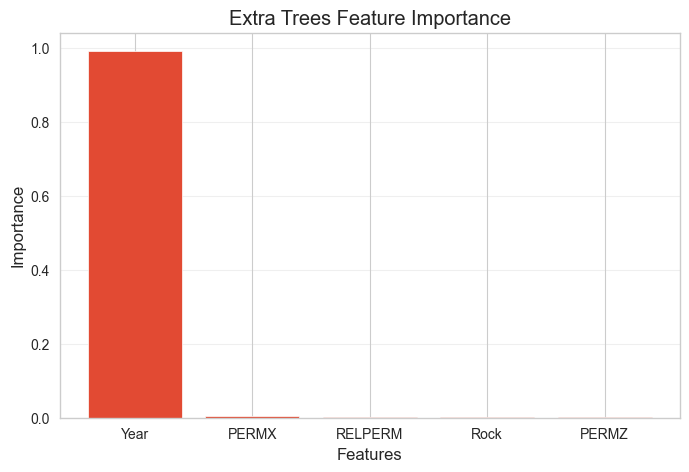

In [22]:
# ============================================================
# FEATURE IMPORTANCE - EXTRA TREES
# ============================================================

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.multioutput import MultiOutputRegressor
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Train on the full dataset
# ------------------------------------------------------------

model = MultiOutputRegressor(

    ExtraTreesRegressor(

        n_estimators=500,

        random_state=42,

        n_jobs=-1

    )

)

model.fit(X, y)

# ------------------------------------------------------------
# Feature Importance
# ------------------------------------------------------------

fwct_importance = model.estimators_[0].feature_importances_

fwpt_importance = model.estimators_[1].feature_importances_

importance = pd.DataFrame({

    "Feature": X.columns,

    "FWCT Importance": fwct_importance,

    "FWPT Importance": fwpt_importance,

})

importance["Average Importance"] = (

    importance["FWCT Importance"]

    +

    importance["FWPT Importance"]

) / 2

importance = importance.sort_values(

    "Average Importance",

    ascending=False

).reset_index(drop=True)

print("=" * 90)
print("FEATURE IMPORTANCE")
print("=" * 90)

display(importance)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(

    importance["Feature"],

    importance["Average Importance"]

)

plt.title("Extra Trees Feature Importance")

plt.ylabel("Importance")

plt.xlabel("Features")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [23]:
# ============================================================
# CREATE HISTORY MATCHING SUMMARY DATASET
# ============================================================

summary_data = []

for (run, rock), df in ml_df.groupby(["Run", "Rock"]):

    summary_data.append({

        "Run": run,

        "Rock": rock,

        "PERMX": df["PERMX"].iloc[0],

        "PERMZ": df["PERMZ"].iloc[0],

        "RELPERM": df["RELPERM"].iloc[0],

        # ----------------------------------------------------
        # FWCT Metrics
        # ----------------------------------------------------

        "FWCT_RMSE": np.sqrt(
            np.mean(df["FWCT_Error"]**2)
        ),

        "FWCT_MAE": np.mean(
            np.abs(df["FWCT_Error"])
        ),

        "FWCT_Bias": np.mean(
            df["FWCT_Error"]
        ),

        "FWCT_Final_Error": df["FWCT_Error"].iloc[-1],

        "FWCT_Max_Error": np.max(
            np.abs(df["FWCT_Error"])
        ),

        "FWCT_Trend_Error": np.mean(
            np.abs(df["FWCT_Trend_Error"])
        ),

        # ----------------------------------------------------
        # FWPT Metrics
        # ----------------------------------------------------

        "FWPT_RMSE": np.sqrt(
            np.mean(df["FWPT_Error"]**2)
        ),

        "FWPT_MAE": np.mean(
            np.abs(df["FWPT_Error"])
        ),

        "FWPT_Bias": np.mean(
            df["FWPT_Error"]
        ),

        "FWPT_Final_Error": df["FWPT_Error"].iloc[-1],

        "FWPT_Max_Error": np.max(
            np.abs(df["FWPT_Error"])
        ),

        "FWPT_Trend_Error": np.mean(
            np.abs(df["FWPT_Trend_Error"])
        )

    })

history_df = pd.DataFrame(summary_data)

print("="*90)
print("HISTORY MATCHING SUMMARY DATASET")
print("="*90)

print("Shape:", history_df.shape)

display(history_df)

HISTORY MATCHING SUMMARY DATASET
Shape: (8, 17)


,Run,Rock,PERMX,PERMZ,RELPERM,FWCT_RMSE,FWCT_MAE,FWCT_Bias,FWCT_Final_Error,FWCT_Max_Error,FWCT_Trend_Error,FWPT_RMSE,FWPT_MAE,FWPT_Bias,FWPT_Final_Error,FWPT_Max_Error,FWPT_Trend_Error
0,R1,0,0.9,1.1,1.1,0.161100,0.101184,-0.095581,0.011022,0.948665,0.027433,1.586441e+07,1.315052e+07,-1.315049e+07,-24031784.0,24360308.0,139535.067230
1,R1,1,0.9,1.1,1.1,0.155457,0.093811,-0.083569,0.021870,0.939947,0.027574,1.309510e+07,1.093357e+07,-1.093354e+07,-18844848.0,19997972.0,122769.078965
2,R2,0,0.9,0.9,0.9,0.151033,0.087326,-0.072639,0.026681,0.962093,0.027715,1.052421e+07,8.763578e+06,-8.763548e+06,-14752016.0,16454232.0,110213.905394
3,R2,1,0.9,0.9,0.9,0.157824,0.094981,-0.088443,0.012759,0.945164,0.027476,1.398031e+07,1.153344e+07,-1.153341e+07,-21191432.0,21608708.0,126968.360680
4,R3,0,1.1,1.1,0.9,0.141854,0.075582,-0.052284,0.027058,0.968940,0.027973,6.147889e+06,4.990422e+06,-4.990392e+06,-8142368.0,10342268.0,90037.179433
5,R3,1,1.1,1.1,0.9,0.145571,0.080073,-0.066643,0.013046,0.954248,0.027644,8.903107e+06,7.182278e+06,-7.182248e+06,-13564056.0,14208900.0,100236.610279
6,R4,0,1.1,0.9,1.1,0.155298,0.091625,-0.088559,-0.009042,0.955962,0.027342,1.364791e+07,1.078956e+07,-1.078953e+07,-23263792.0,23263792.0,129095.423086
7,R4,1,1.1,0.9,1.1,0.145571,0.080073,-0.066643,0.013046,0.954248,0.027644,1.112256e+07,8.833466e+06,-8.833437e+06,-18260144.0,18274348.0,112686.495425


In [24]:
# ============================================================
# RANK HISTORY MATCHING RUNS
# ============================================================

history_df["Overall_Score"] = (

    history_df["FWCT_RMSE"] /

    history_df["FWCT_RMSE"].max()

)

+ (

    history_df["FWPT_RMSE"] /

    history_df["FWPT_RMSE"].max()

)

history_df = history_df.sort_values(

    "Overall_Score"

).reset_index(drop=True)

print("="*90)
print("HISTORY MATCHING RANKING")
print("="*90)

display(

    history_df[

        [

            "Run",

            "Rock",

            "PERMX",

            "PERMZ",

            "RELPERM",

            "FWCT_RMSE",

            "FWPT_RMSE",

            "Overall_Score"

        ]

    ]

)

HISTORY MATCHING RANKING


,Run,Rock,PERMX,PERMZ,RELPERM,FWCT_RMSE,FWPT_RMSE,Overall_Score
0,R3,0,1.1,1.1,0.9,0.141854,6.147889e+06,0.880535
1,R3,1,1.1,1.1,0.9,0.145571,8.903107e+06,0.903607
2,R4,1,1.1,0.9,1.1,0.145571,1.112256e+07,0.903607
3,R2,0,0.9,0.9,0.9,0.151033,1.052421e+07,0.937511
4,R4,0,1.1,0.9,1.1,0.155298,1.364791e+07,0.963982
5,R1,1,0.9,1.1,1.1,0.155457,1.309510e+07,0.964967
6,R2,1,0.9,0.9,0.9,0.157824,1.398031e+07,0.979660
7,R1,0,0.9,1.1,1.1,0.161100,1.586441e+07,1.000000


In [25]:
# ============================================================
# FINAL SATURATION HISTORY MATCH RECOMMENDATION
# ============================================================

best_match = history_df.iloc[0]

print("=" * 90)
print("FINAL HISTORY MATCH RECOMMENDATION")
print("=" * 90)

print(f"Recommended Run      : {best_match['Run']}")
print(f"Recommended Rock     : Rock {int(best_match['Rock']) + 1}")

print()

print(f"Recommended PERMX    : {best_match['PERMX']}")
print(f"Recommended PERMZ    : {best_match['PERMZ']}")
print(f"Recommended RELPERM  : {best_match['RELPERM']}")

print()

print(f"FWCT RMSE            : {best_match['FWCT_RMSE']:.6f}")
print(f"FWPT RMSE            : {best_match['FWPT_RMSE']:,.2f}")

print(f"Overall Score        : {best_match['Overall_Score']:.4f}")

# ============================================================
# SAVE PARAMETERS
# ============================================================

recommended_parameters = pd.DataFrame({

    "Parameter":[
        "PERMX",
        "PERMZ",
        "RELPERM"
    ],

    "Recommended Value":[
        best_match["PERMX"],
        best_match["PERMZ"],
        best_match["RELPERM"]
    ]

})

print("\nRecommended Parameters")

display(recommended_parameters)

recommended_parameters.to_excel(

    "Recommended_Saturation_Parameters.xlsx",

    index=False

)

FINAL HISTORY MATCH RECOMMENDATION
Recommended Run      : R3
Recommended Rock     : Rock 1

Recommended PERMX    : 1.1
Recommended PERMZ    : 1.1
Recommended RELPERM  : 0.9

FWCT RMSE            : 0.141854
FWPT RMSE            : 6,147,888.73
Overall Score        : 0.8805

Recommended Parameters


,Parameter,Recommended Value
0,PERMX,1.1
1,PERMZ,1.1
2,RELPERM,0.9


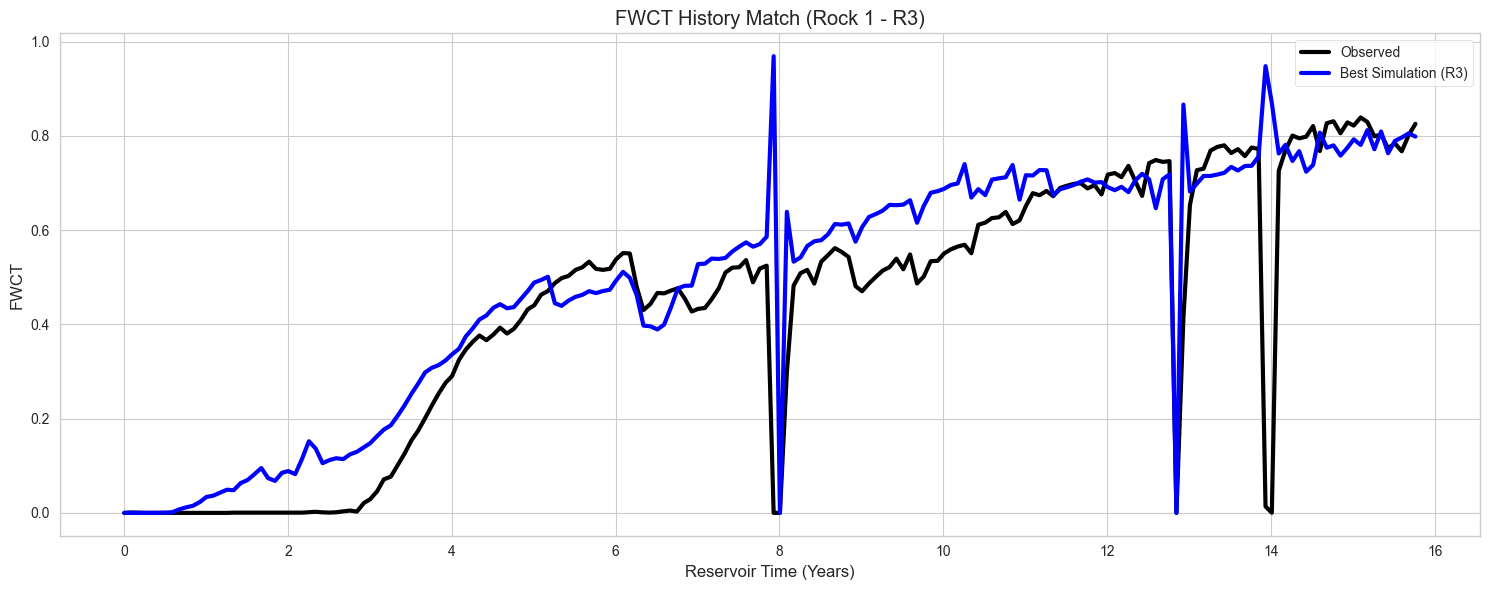

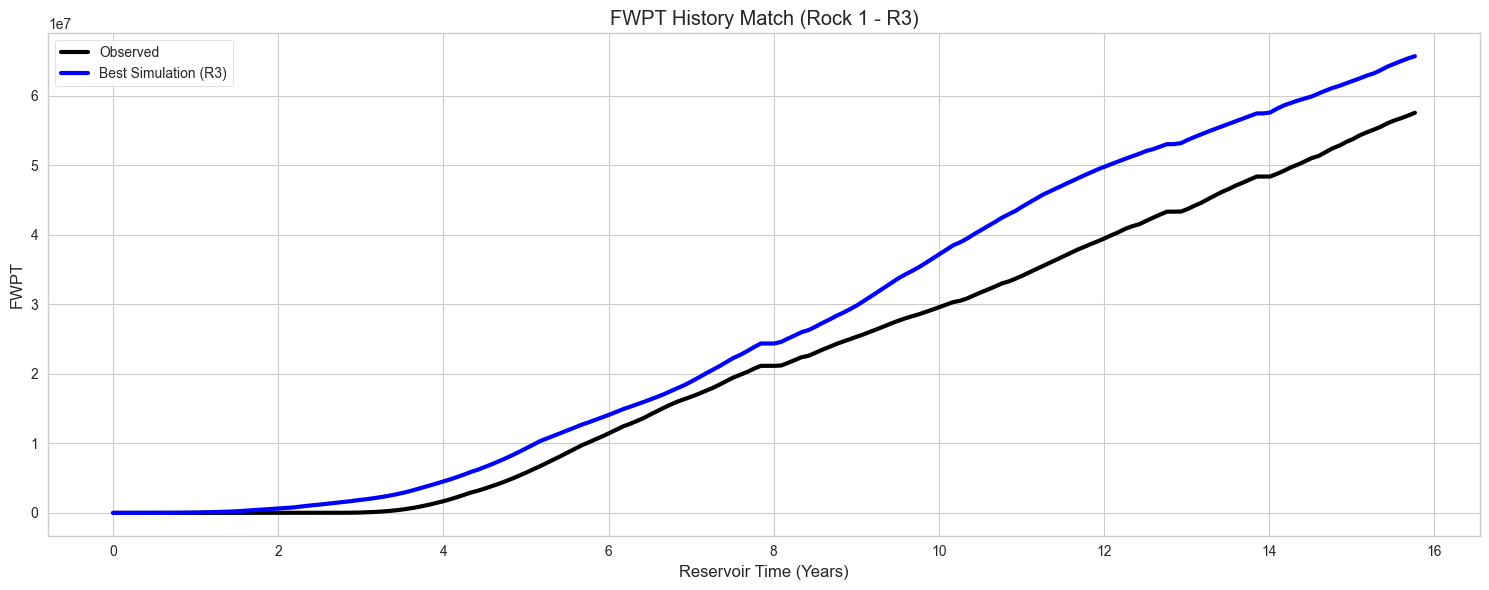

In [27]:
# =============================================================================
# FWCT HISTORY MATCH (BEST RUN - ROCK 1)
# =============================================================================

best_run = best_match["Run"]      # e.g. R1, R2, R3 or R4

simulation_column = f"FWCT {best_run}R1"

plt.figure(figsize=(15,6))

# Observed
plt.plot(
    realizations["SIM_Year"],
    realizations["FWCT OBS"],
    color="black",
    linewidth=3,
    label="Observed"
)

# Best Simulation
plt.plot(
    realizations["SIM_Year"],
    realizations[simulation_column],
    color="blue",
    linewidth=3,
    label=f"Best Simulation ({best_run})"
)

plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWCT")
plt.title(f"FWCT History Match (Rock 1 - {best_run})")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# =============================================================================
# FWPT HISTORY MATCH (BEST RUN - ROCK 1)
# =============================================================================

simulation_column = f"FWPT {best_run}R1"

plt.figure(figsize=(15,6))

# Observed
plt.plot(
    realizations["SIM_Year"],
    realizations["FWPTH OBS"],
    color="black",
    linewidth=3,
    label="Observed"
)

# Best Simulation
plt.plot(
    realizations["SIM_Year"],
    realizations[simulation_column],
    color="blue",
    linewidth=3,
    label=f"Best Simulation ({best_run})"
)

plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWPT")
plt.title(f"FWPT History Match (Rock 1 - {best_run})")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [28]:
# ============================================================
# TRAIN FINAL TUNED XGBOOST SURROGATE
# ============================================================

from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

best_surrogate = MultiOutputRegressor(

    XGBRegressor(

        n_estimators=500,

        max_depth=6,

        learning_rate=0.10,

        subsample=0.90,

        colsample_bytree=0.80,

        objective="reg:squarederror",

        random_state=42,

        n_jobs=-1

    )

)

best_surrogate.fit(

    X,

    y

)

print("=" * 80)
print("FINAL TUNED XGBOOST SURROGATE TRAINED")
print("=" * 80)

FINAL TUNED XGBOOST SURROGATE TRAINED


In [29]:
# ============================================================
# IMPORT OPTIMIZER
# ============================================================

from scipy.optimize import differential_evolution

print("Optimizer Ready")

# ============================================================
# SURROGATE OBJECTIVE FUNCTION
# ============================================================

# ------------------------------------------------------------
# Rock Encoding
# Rock 0 = Rock1
# Rock 1 = Rock2
# ------------------------------------------------------------

rock1 = np.zeros(len(realizations))

rock2 = np.ones(len(realizations))

# ------------------------------------------------------------
# Objective Function
# ------------------------------------------------------------

def objective(parameters):

    permx, permz, relperm = parameters

    # --------------------------------------------------------
    # Rock 1 Prediction
    # --------------------------------------------------------

    rock1_df = pd.DataFrame({

        "PERMX": permx,

        "PERMZ": permz,

        "RELPERM": relperm,

        "Rock": rock1,

        "Year": realizations["SIM_Year"]

    })

    rock1_df = rock1_df[feature_columns]

    pred1 = best_surrogate.predict(rock1_df)

    # --------------------------------------------------------
    # Rock 2 Prediction
    # --------------------------------------------------------

    rock2_df = pd.DataFrame({

        "PERMX": permx,

        "PERMZ": permz,

        "RELPERM": relperm,

        "Rock": rock2,

        "Year": realizations["SIM_Year"]

    })

    rock2_df = rock2_df[feature_columns]

    pred2 = best_surrogate.predict(rock2_df)

    # --------------------------------------------------------
    # Compute Errors
    # --------------------------------------------------------

    fwct_rmse = (

        np.sqrt(

            mean_squared_error(

                realizations["FWCT OBS"],

                pred1[:,0]

            )

        )

        +

        np.sqrt(

            mean_squared_error(

                realizations["FWCT_R2 OBS"],

                pred2[:,0]

            )

        )

    )

    fwpt_rmse = (

        np.sqrt(

            mean_squared_error(

                realizations["FWPTH OBS"],

                pred1[:,1]

            )

        )

        +

        np.sqrt(

            mean_squared_error(

                realizations["FWPTH_R2 OBS"],

                pred2[:,1]

            )

        )

    )

    return fwct_rmse + fwpt_rmse

Optimizer Ready


In [30]:
# ============================================================
# SURROGATE OPTIMIZATION
# ============================================================

bounds = [

    (0.90,1.10),

    (0.90,1.10),

    (0.90,1.10)

]

result = differential_evolution(

    objective,

    bounds,

    seed=42,

    maxiter=100,

    popsize=20,

    tol=1e-6

)

print("="*80)
print("OPTIMIZATION FINISHED")
print("="*80)

print(result)

# ============================================================
# RECOMMENDED PARAMETERS
# ============================================================

best_params = result.x

recommended_parameters = pd.DataFrame({

    "Parameter":[

        "PERMX",

        "PERMZ",

        "RELPERM"

    ],

    "Recommended Value":best_params

})

print("="*80)
print("SURROGATE RECOMMENDATION")
print("="*80)

display(recommended_parameters)

recommended_parameters.to_excel(

    "Recommended_Surrogate_Parameters.xlsx",

    index=False

)

# ============================================================
# PREDICT USING OPTIMIZED PARAMETERS
# ============================================================

prediction_rock1 = pd.DataFrame({

    "PERMX": best_params[0],

    "PERMZ": best_params[1],

    "RELPERM": best_params[2],

    "Rock": np.zeros(len(realizations)),

    "Year": realizations["SIM_Year"]

})

prediction_rock1 = prediction_rock1[feature_columns]

prediction_rock2 = pd.DataFrame({

    "PERMX": best_params[0],

    "PERMZ": best_params[1],

    "RELPERM": best_params[2],

    "Rock": np.ones(len(realizations)),

    "Year": realizations["SIM_Year"]

})

prediction_rock2 = prediction_rock2[feature_columns]

pred1 = best_surrogate.predict(prediction_rock1)

pred2 = best_surrogate.predict(prediction_rock2)

print("Prediction Complete")

OPTIMIZATION FINISHED
             message: Optimization terminated successfully.
             success: True
                 fun: 24504309.0794316
                   x: [ 9.879e-01  1.092e+00  1.072e+00]
                 nit: 1
                nfev: 124
          population: [[ 9.879e-01  1.092e+00  1.072e+00]
                       [ 1.058e+00  1.073e+00  1.012e+00]
                       ...
                       [ 9.129e-01  1.041e+00  1.065e+00]
                       [ 1.005e+00  9.113e-01  9.772e-01]]
 population_energies: [ 2.450e+07  2.450e+07 ...  2.450e+07  2.450e+07]
SURROGATE RECOMMENDATION


,Parameter,Recommended Value
0,PERMX,0.987862
1,PERMZ,1.091903
2,RELPERM,1.072116


Prediction Complete


OPTIMIZED SATURATION PREDICTION


,PERMX,PERMZ,RELPERM,Rock,Year,Predicted_FWCT,Predicted_FWPT
0,0.9,1.1,1.1,0,0.000000,0.000558,-3655.761475
1,0.9,1.1,1.1,0,0.084932,0.000595,-5735.264160
2,0.9,1.1,1.1,0,0.167123,0.000595,-5677.754395
3,0.9,1.1,1.1,0,0.252055,0.000595,2138.541992
4,0.9,1.1,1.1,0,0.334247,0.000725,-21.282234


,PERMX,PERMZ,RELPERM,Rock,Year,Predicted_FWCT,Predicted_FWPT
0,0.9,1.1,1.1,1,0.000000,0.000156,7823.859375
1,0.9,1.1,1.1,1,0.084932,0.000192,5744.357422
2,0.9,1.1,1.1,1,0.167123,0.000192,1909.103394
3,0.9,1.1,1.1,1,0.252055,0.000192,6522.247070
4,0.9,1.1,1.1,1,0.334247,0.000323,4362.411133


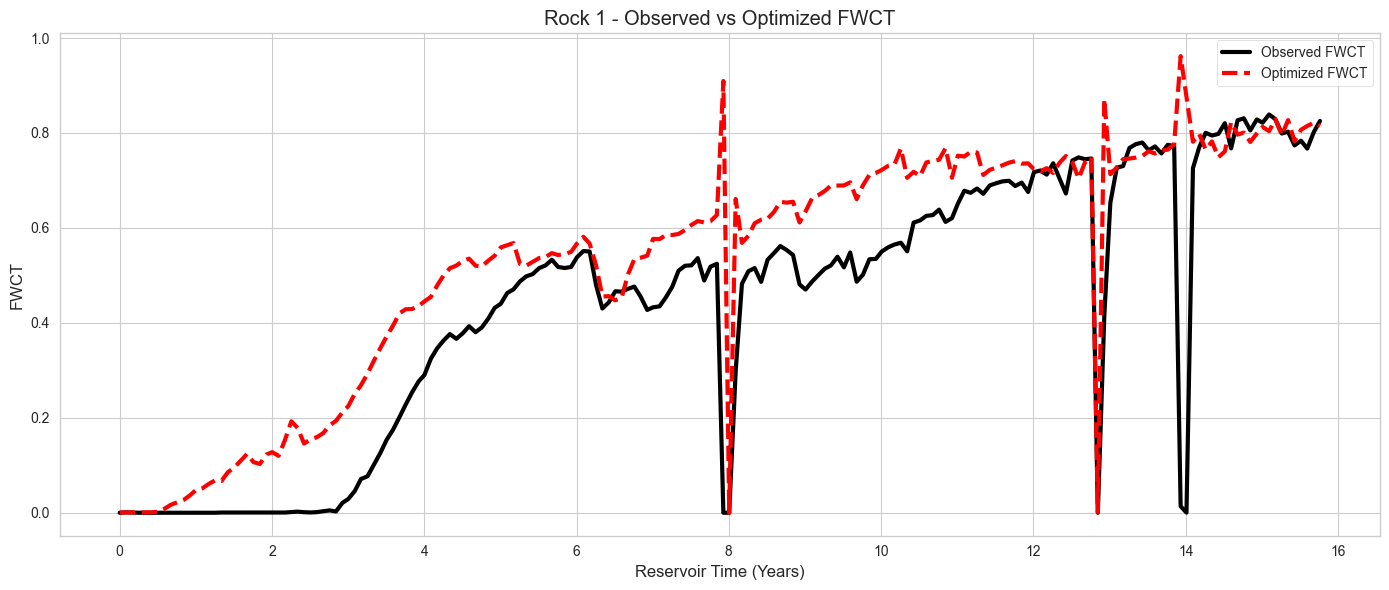

In [31]:
# =============================================================================
# PREDICT SATURATION USING OPTIMIZED PARAMETERS
# =============================================================================

# ----------------------------------------------------------
# Optimized Parameters
# ----------------------------------------------------------

best_params = [

    0.9,      # PERMX

    1.1,      # PERMZ

    1.1       # RELPERM

]

# =============================================================================
# ROCK 1
# =============================================================================

rock1_prediction = pd.DataFrame({

    "PERMX": np.full(len(realizations), best_params[0]),

    "PERMZ": np.full(len(realizations), best_params[1]),

    "RELPERM": np.full(len(realizations), best_params[2]),

    "Rock": np.zeros(len(realizations), dtype=int),

    "Year": realizations["SIM_Year"]

})

rock1_prediction = rock1_prediction[feature_columns]

pred1 = best_surrogate.predict(rock1_prediction)

rock1_prediction["Predicted_FWCT"] = pred1[:,0]

rock1_prediction["Predicted_FWPT"] = pred1[:,1]

# =============================================================================
# ROCK 2
# =============================================================================

rock2_prediction = pd.DataFrame({

    "PERMX": np.full(len(realizations), best_params[0]),

    "PERMZ": np.full(len(realizations), best_params[1]),

    "RELPERM": np.full(len(realizations), best_params[2]),

    "Rock": np.ones(len(realizations), dtype=int),

    "Year": realizations["SIM_Year"]

})

rock2_prediction = rock2_prediction[feature_columns]

pred2 = best_surrogate.predict(rock2_prediction)

rock2_prediction["Predicted_FWCT"] = pred2[:,0]

rock2_prediction["Predicted_FWPT"] = pred2[:,1]

print("="*80)
print("OPTIMIZED SATURATION PREDICTION")
print("="*80)

display(rock1_prediction.head())

display(rock2_prediction.head())

# =============================================================================
# HISTORY MATCH - ROCK 1
# =============================================================================

plt.figure(figsize=(14,6))

plt.plot(

    realizations["SIM_Year"],

    realizations["FWCT OBS"],

    color="black",

    linewidth=3,

    label="Observed FWCT"

)

plt.plot(

    realizations["SIM_Year"],

    rock1_prediction["Predicted_FWCT"],

    color="red",

    linestyle="--",

    linewidth=3,

    label="Optimized FWCT"

)

plt.xlabel("Reservoir Time (Years)")

plt.ylabel("FWCT")

plt.title("Rock 1 - Observed vs Optimized FWCT")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


In [32]:
# =============================================================================
# PREDICT USING OPTIMIZED PARAMETERS
# =============================================================================

opt_permX = best_params[0]
opt_permZ = best_params[1]
opt_relperm = best_params[2]

# ---------- Rock 1 ----------

rock1_prediction = pd.DataFrame({

    "PERMX": np.full(len(realizations), opt_permX),

    "PERMZ": np.full(len(realizations), opt_permZ),

    "RELPERM": np.full(len(realizations), opt_relperm),

    "Rock": np.zeros(len(realizations), dtype=int),

    "Year": realizations["SIM_Year"]

})

rock1_prediction = rock1_prediction[feature_columns]

pred1 = best_surrogate.predict(rock1_prediction)

rock1_prediction["Predicted_FWCT"] = pred1[:,0]
rock1_prediction["Predicted_FWPT"] = pred1[:,1]

# ---------- Rock 2 ----------

rock2_prediction = pd.DataFrame({

    "PERMX": np.full(len(realizations), opt_permX),

    "PERMZ": np.full(len(realizations), opt_permZ),

    "RELPERM": np.full(len(realizations), opt_relperm),

    "Rock": np.ones(len(realizations), dtype=int),

    "Year": realizations["SIM_Year"]

})

rock2_prediction = rock2_prediction[feature_columns]

pred2 = best_surrogate.predict(rock2_prediction)

rock2_prediction["Predicted_FWCT"] = pred2[:,0]
rock2_prediction["Predicted_FWPT"] = pred2[:,1]

print("Prediction Complete")

Prediction Complete


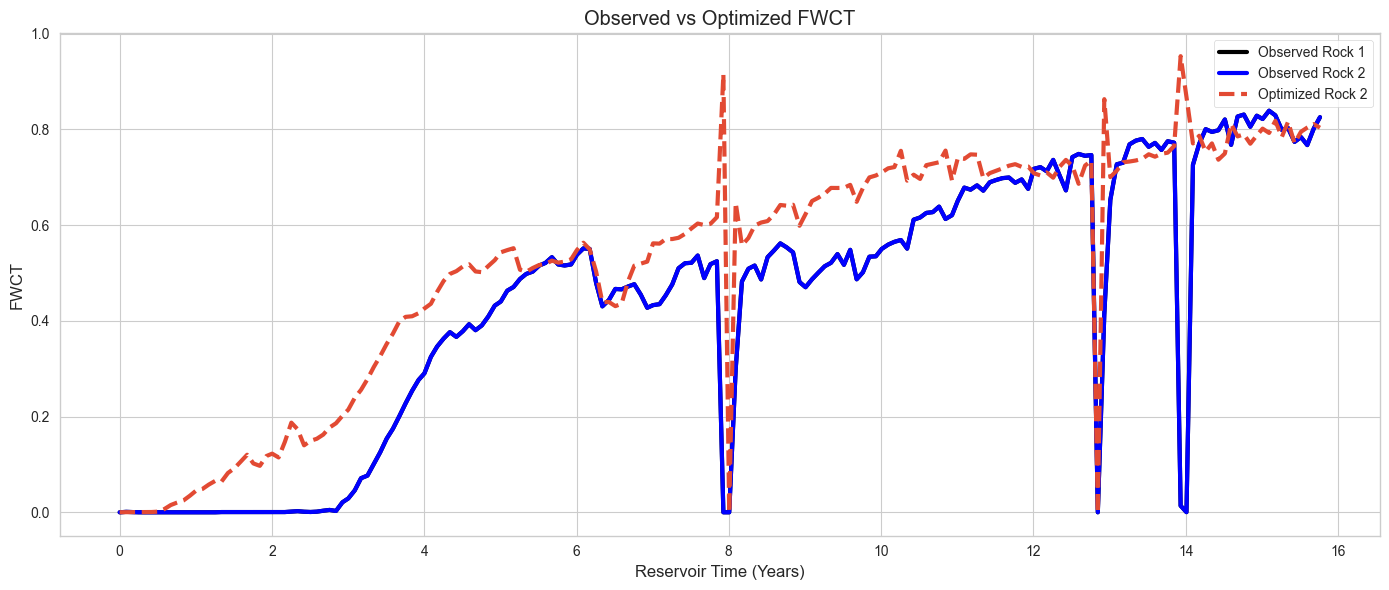

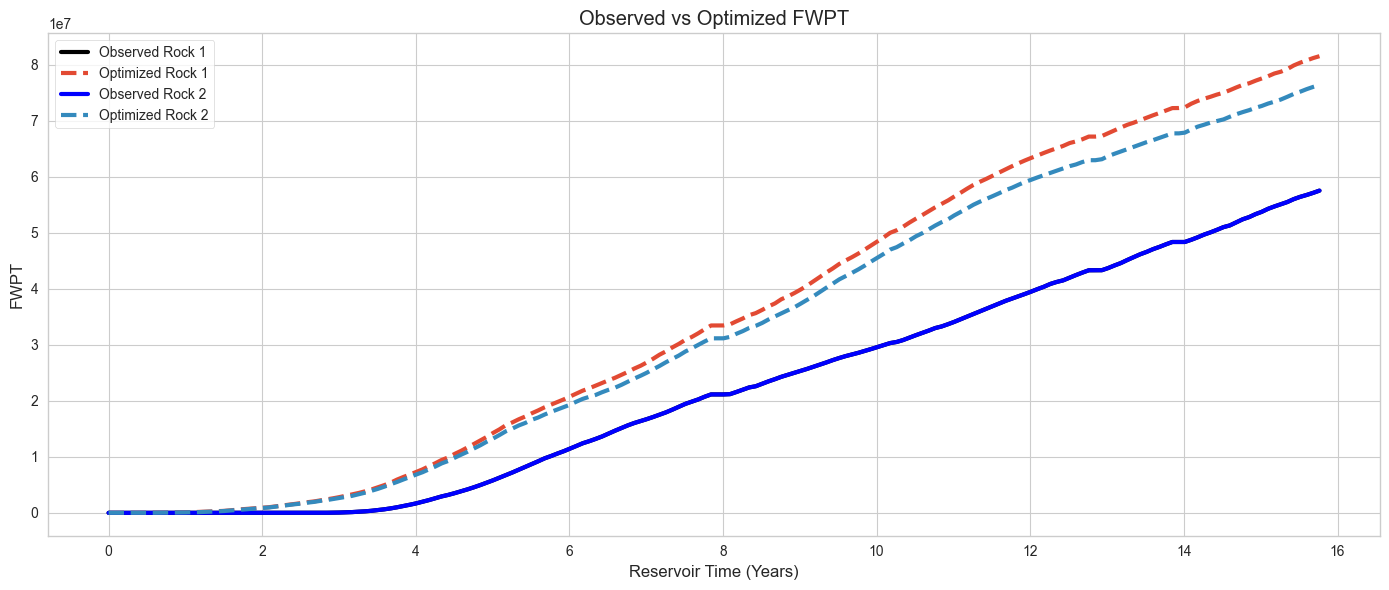

In [33]:
# =============================================================================
# FWCT HISTORY MATCH
# =============================================================================

plt.figure(figsize=(14,6))

# Rock 1

plt.plot(

    realizations["SIM_Year"],

    realizations["FWCT OBS"],

    color="black",

    linewidth=3,

    label="Observed Rock 1"

)


# Rock 2

plt.plot(

    realizations["SIM_Year"],

    realizations["FWCT_R2 OBS"],

    color="blue",

    linewidth=3,

    label="Observed Rock 2"

)

plt.plot(

    realizations["SIM_Year"],

    rock2_prediction["Predicted_FWCT"],

    "--",

    linewidth=3,

    label="Optimized Rock 2"

)

plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWCT")
plt.title("Observed vs Optimized FWCT")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# =============================================================================
# FWPT HISTORY MATCH
# =============================================================================

plt.figure(figsize=(14,6))

# Rock 1

plt.plot(

    realizations["SIM_Year"],

    realizations["FWPTH OBS"],

    color="black",

    linewidth=3,

    label="Observed Rock 1"

)

plt.plot(

    realizations["SIM_Year"],

    rock1_prediction["Predicted_FWPT"],

    "--",

    linewidth=3,

    label="Optimized Rock 1"

)

# Rock 2

plt.plot(

    realizations["SIM_Year"],

    realizations["FWPTH_R2 OBS"],

    color="blue",

    linewidth=3,

    label="Observed Rock 2"

)

plt.plot(

    realizations["SIM_Year"],

    rock2_prediction["Predicted_FWPT"],

    "--",

    linewidth=3,

    label="Optimized Rock 2"

)

plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWPT")
plt.title("Observed vs Optimized FWPT")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

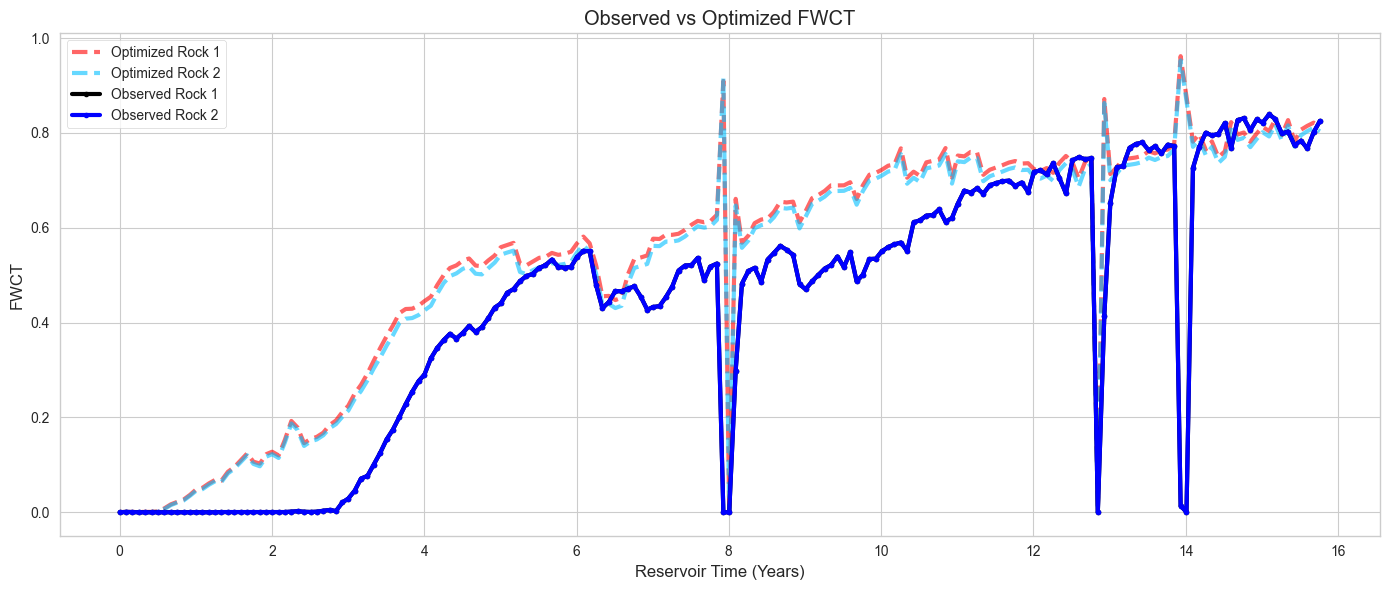

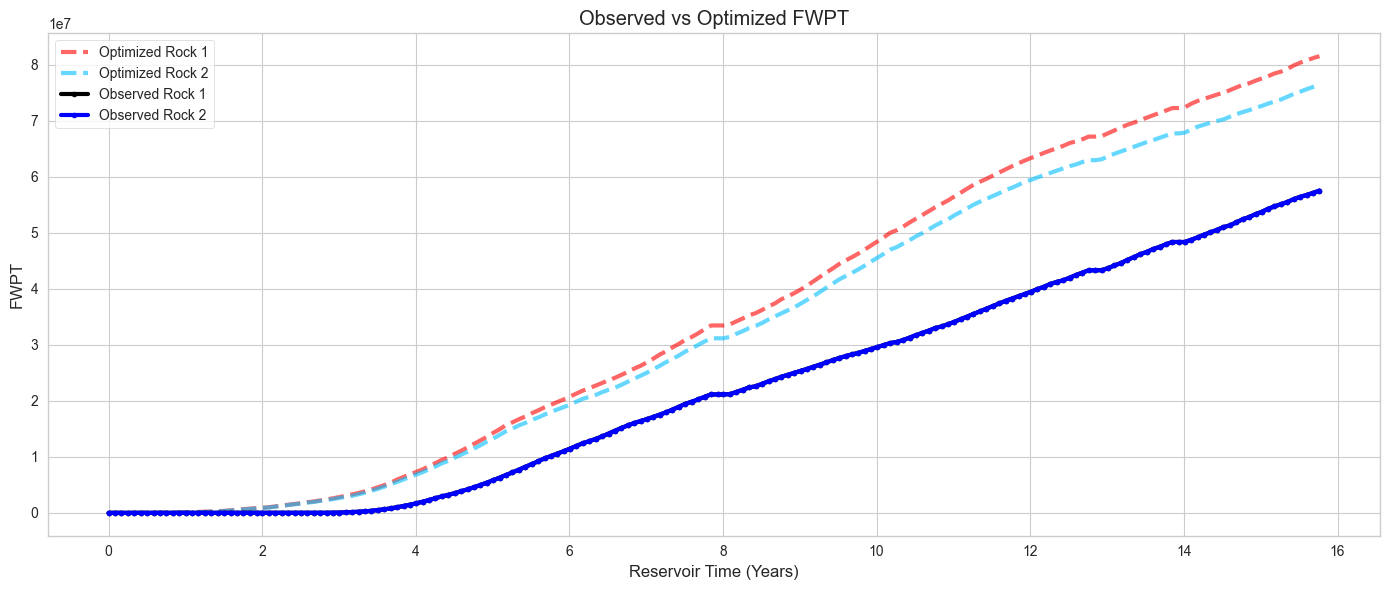

In [34]:
# =============================================================================
# FWCT HISTORY MATCH
# =============================================================================

plt.figure(figsize=(14,6))

# ----------------------------------------------------------
# Optimized Rock 1
# ----------------------------------------------------------

plt.plot(

    realizations["SIM_Year"],

    rock1_prediction["Predicted_FWCT"],

    "--",

    color="red",

    linewidth=3,

    alpha=0.6,

    label="Optimized Rock 1"

)

# ----------------------------------------------------------
# Optimized Rock 2
# ----------------------------------------------------------

plt.plot(

    realizations["SIM_Year"],

    rock2_prediction["Predicted_FWCT"],

    "--",

    color="deepskyblue",

    linewidth=3,

    alpha=0.6,

    label="Optimized Rock 2"

)

# ----------------------------------------------------------
# Observed Rock 1
# ----------------------------------------------------------

plt.plot(

    realizations["SIM_Year"],

    realizations["FWCT OBS"],

    color="black",

    linewidth=3,

    marker="o",

    markersize=3,

    zorder=10,

    label="Observed Rock 1"

)

# ----------------------------------------------------------
# Observed Rock 2
# ----------------------------------------------------------

plt.plot(

    realizations["SIM_Year"],

    realizations["FWCT_R2 OBS"],

    color="blue",

    linewidth=3,

    marker="o",

    markersize=3,

    zorder=10,

    label="Observed Rock 2"

)

plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWCT")
plt.title("Observed vs Optimized FWCT")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


# =============================================================================
# FWPT HISTORY MATCH
# =============================================================================

plt.figure(figsize=(14,6))

# ----------------------------------------------------------
# Optimized Rock 1
# ----------------------------------------------------------

plt.plot(

    realizations["SIM_Year"],

    rock1_prediction["Predicted_FWPT"],

    "--",

    color="red",

    linewidth=3,

    alpha=0.6,

    label="Optimized Rock 1"

)

# ----------------------------------------------------------
# Optimized Rock 2
# ----------------------------------------------------------

plt.plot(

    realizations["SIM_Year"],

    rock2_prediction["Predicted_FWPT"],

    "--",

    color="deepskyblue",

    linewidth=3,

    alpha=0.6,

    label="Optimized Rock 2"

)

# ----------------------------------------------------------
# Observed Rock 1
# ----------------------------------------------------------

plt.plot(

    realizations["SIM_Year"],

    realizations["FWPTH OBS"],

    color="black",

    linewidth=3,

    marker="o",

    markersize=3,

    zorder=10,

    label="Observed Rock 1"

)

# ----------------------------------------------------------
# Observed Rock 2
# ----------------------------------------------------------

plt.plot(

    realizations["SIM_Year"],

    realizations["FWPTH_R2 OBS"],

    color="blue",

    linewidth=3,

    marker="o",

    markersize=3,

    zorder=10,

    label="Observed Rock 2"

)

plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWPT")
plt.title("Observed vs Optimized FWPT")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [34]:
print(realizations.columns.tolist())

print(realizations["FWCT OBS"].head())

print(realizations["FWCT_R2 OBS"].head())

print(realizations["FWCT OBS"].equals(realizations["FWCT_R2 OBS"]))

['SIM_Year', 'FWCT R1R1', 'FWCT R2R1', 'FWCT R3R1', 'FWCT R4R1', 'FWCT R1R2', 'FWCT R2R2', 'FWCT R3R2', 'FWCT R4R2', 'FWPT R1R1', 'FWPT R2R1', 'FWPT R3R1', 'FWPT R4R1', 'FWPT R1R2', 'FWPT R2R2', 'FWPT R3R2', 'FWPT R4R2', 'FWPTH OBS', 'FWPTH_R2 OBS', 'FWCT OBS', 'FWCT_R2 OBS']
0    0.000000
1    0.000885
2    0.000469
3    0.000033
4    0.000015
Name: FWCT OBS, dtype: float64
0    0.000000
1    0.000885
2    0.000469
3    0.000033
4    0.000015
Name: FWCT_R2 OBS, dtype: float64
True


In [35]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

X = ml_df[
    [
        "PERMX",
        "PERMZ",
        "RELPERM",
        "Rock",
        "Year"
    ]
].copy()

# ------------------------------------------------------------
# Interaction Features
# ------------------------------------------------------------

X["PERMX_x_PERMZ"] = (
    X["PERMX"] * X["PERMZ"]
)

X["PERMX_x_RELPERM"] = (
    X["PERMX"] * X["RELPERM"]
)

X["PERMZ_x_RELPERM"] = (
    X["PERMZ"] * X["RELPERM"]
)

# ------------------------------------------------------------
# Ratio Features
# ------------------------------------------------------------

X["PERMX_DIV_PERMZ"] = (
    X["PERMX"] /
    (X["PERMZ"] + 1e-6)
)

X["PERMZ_DIV_PERMX"] = (
    X["PERMZ"] /
    (X["PERMX"] + 1e-6)
)

# ------------------------------------------------------------
# Time Features
# ------------------------------------------------------------

X["Year_Squared"] = (
    X["Year"] ** 2
)

X["Year_Cubed"] = (
    X["Year"] ** 3
)

X["Log_Year"] = np.log1p(
    X["Year"]
)

# ------------------------------------------------------------
# Parameter-Time Interaction
# ------------------------------------------------------------

X["PERMX_x_Year"] = (
    X["PERMX"] * X["Year"]
)

X["PERMZ_x_Year"] = (
    X["PERMZ"] * X["Year"]
)

X["RELPERM_x_Year"] = (
    X["RELPERM"] * X["Year"]
)

# ------------------------------------------------------------
# Reservoir Flow Indicator
# ------------------------------------------------------------

X["Reservoir_Quality"] = (

    X["PERMX"]

    *

    X["PERMZ"]

    *

    X["RELPERM"]

)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("="*80)
print("ENGINEERED FEATURES")
print("="*80)

print("Total Features :", len(X.columns))

display(X.head())

ENGINEERED FEATURES
Total Features : 17


,PERMX,PERMZ,RELPERM,Rock,Year,PERMX_x_PERMZ,PERMX_x_RELPERM,PERMZ_x_RELPERM,PERMX_DIV_PERMZ,PERMZ_DIV_PERMX,Year_Squared,Year_Cubed,Log_Year,PERMX_x_Year,PERMZ_x_Year,RELPERM_x_Year,Reservoir_Quality
0,0.9,1.1,1.1,0,0.000000,0.99,0.99,1.21,0.818181,1.222221,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.089
1,0.9,1.1,1.1,0,0.084932,0.99,0.99,1.21,0.818181,1.222221,0.007213,0.000613,0.081517,0.076438,0.093425,0.093425,1.089
2,0.9,1.1,1.1,0,0.167123,0.99,0.99,1.21,0.818181,1.222221,0.027930,0.004668,0.154542,0.150411,0.183836,0.183836,1.089
3,0.9,1.1,1.1,0,0.252055,0.99,0.99,1.21,0.818181,1.222221,0.063532,0.016013,0.224786,0.226849,0.277260,0.277260,1.089
4,0.9,1.1,1.1,0,0.334247,0.99,0.99,1.21,0.818181,1.222221,0.111721,0.037342,0.288367,0.300822,0.367671,0.367671,1.089


In [36]:
# ============================================================
# MODEL COMPARISON (ENGINEERED FEATURES)
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from catboost import CatBoostRegressor

# ------------------------------------------------------------
# Try importing XGBoost
# ------------------------------------------------------------

try:

    from xgboost import XGBRegressor

    xgb_available = True

except ImportError:

    xgb_available = False

    print("XGBoost not installed...Skipping")


# ============================================================
# FEATURES
# ============================================================

print("="*80)
print("FEATURES USED")
print("="*80)

print(f"Number of Features : {X.shape[1]}")
display(X.head())

# ============================================================
# TARGETS
# ============================================================

y = ml_df[
    [
        "Simulated_FWCT",
        "Simulated_FWPT"
    ]
]

# ============================================================
# MODELS
# ============================================================

models = {

    "Random Forest": MultiOutputRegressor(

        RandomForestRegressor(

            n_estimators=1000,

            max_features="sqrt",

            random_state=42,

            n_jobs=-1

        )

    ),

    "Extra Trees": MultiOutputRegressor(

        ExtraTreesRegressor(

            n_estimators=1000,

            max_features="sqrt",

            random_state=42,

            n_jobs=-1

        )

    ),

    "Gradient Boosting": MultiOutputRegressor(

        GradientBoostingRegressor(

            n_estimators=500,

            learning_rate=0.03,

            max_depth=4,

            subsample=0.9,

            random_state=42

        )

    ),

    "CatBoost": MultiOutputRegressor(

        CatBoostRegressor(

            iterations=1500,

            depth=8,

            learning_rate=0.03,

            loss_function="RMSE",

            random_seed=42,

            verbose=False

        )

    )

}

if xgb_available:

    models["XGBoost"] = MultiOutputRegressor(

        XGBRegressor(

            n_estimators=1000,

            max_depth=6,

            learning_rate=0.03,

            subsample=0.9,

            colsample_bytree=0.9,

            objective="reg:squarederror",

            random_state=42,

            n_jobs=-1

        )

    )

# ============================================================
# LOGO CROSS VALIDATION
# ============================================================

logo = LeaveOneGroupOut()

groups = ml_df["Run"]

results = []

for model_name, model in models.items():

    print("="*80)
    print(model_name)
    print("="*80)

    predictions = np.zeros(y.shape)

    for train_idx, test_idx in logo.split(
        X,
        y,
        groups
    ):

        model.fit(
            X.iloc[train_idx],
            y.iloc[train_idx]
        )

        predictions[test_idx] = model.predict(
            X.iloc[test_idx]
        )

    # --------------------------------------------------------
    # FWCT
    # --------------------------------------------------------

    fwct_rmse = np.sqrt(
        mean_squared_error(
            y["Simulated_FWCT"],
            predictions[:,0]
        )
    )

    fwct_r2 = r2_score(
        y["Simulated_FWCT"],
        predictions[:,0]
    )

    fwct_nrmse = fwct_rmse / (
        y["Simulated_FWCT"].max()
        -
        y["Simulated_FWCT"].min()
    )

    # --------------------------------------------------------
    # FWPT
    # --------------------------------------------------------

    fwpt_rmse = np.sqrt(
        mean_squared_error(
            y["Simulated_FWPT"],
            predictions[:,1]
        )
    )

    fwpt_r2 = r2_score(
        y["Simulated_FWPT"],
        predictions[:,1]
    )

    fwpt_nrmse = fwpt_rmse / (
        y["Simulated_FWPT"].max()
        -
        y["Simulated_FWPT"].min()
    )

    results.append({

        "Model": model_name,

        "FWCT_RMSE": round(fwct_rmse,6),

        "FWCT_NRMSE": round(fwct_nrmse,4),

        "FWCT_R2": round(fwct_r2,4),

        "FWPT_RMSE": round(fwpt_rmse,2),

        "FWPT_NRMSE": round(fwpt_nrmse,4),

        "FWPT_R2": round(fwpt_r2,4)

    })

# ============================================================
# RESULTS
# ============================================================

results_df = (

    pd.DataFrame(results)

    .sort_values(

        by="FWPT_R2",

        ascending=False

    )

    .reset_index(drop=True)

)

print()
print("="*100)
print("MODEL COMPARISON")
print("="*100)

display(results_df)

FEATURES USED
Number of Features : 17


,PERMX,PERMZ,RELPERM,Rock,Year,PERMX_x_PERMZ,PERMX_x_RELPERM,PERMZ_x_RELPERM,PERMX_DIV_PERMZ,PERMZ_DIV_PERMX,Year_Squared,Year_Cubed,Log_Year,PERMX_x_Year,PERMZ_x_Year,RELPERM_x_Year,Reservoir_Quality
0,0.9,1.1,1.1,0,0.000000,0.99,0.99,1.21,0.818181,1.222221,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.089
1,0.9,1.1,1.1,0,0.084932,0.99,0.99,1.21,0.818181,1.222221,0.007213,0.000613,0.081517,0.076438,0.093425,0.093425,1.089
2,0.9,1.1,1.1,0,0.167123,0.99,0.99,1.21,0.818181,1.222221,0.027930,0.004668,0.154542,0.150411,0.183836,0.183836,1.089
3,0.9,1.1,1.1,0,0.252055,0.99,0.99,1.21,0.818181,1.222221,0.063532,0.016013,0.224786,0.226849,0.277260,0.277260,1.089
4,0.9,1.1,1.1,0,0.334247,0.99,0.99,1.21,0.818181,1.222221,0.111721,0.037342,0.288367,0.300822,0.367671,0.367671,1.089


Random Forest
Extra Trees
Gradient Boosting
CatBoost
XGBoost

MODEL COMPARISON


,Model,FWCT_RMSE,FWCT_NRMSE,FWCT_R2,FWPT_RMSE,FWPT_NRMSE,FWPT_R2
0,Extra Trees,0.052475,0.0541,0.9603,4731490.17,0.0580,0.9657
1,Random Forest,0.042022,0.0433,0.9746,4741531.56,0.0581,0.9656
2,XGBoost,0.029753,0.0307,0.9873,5083657.99,0.0623,0.9604
3,Gradient Boosting,0.036475,0.0376,0.9808,5464872.93,0.0670,0.9542
4,CatBoost,0.033751,0.0348,0.9836,5618003.37,0.0689,0.9516


In [37]:
# ============================================================
# XGBOOST HYPERPARAMETER SEARCH
# ============================================================

from sklearn.model_selection import LeaveOneGroupOut, ParameterGrid
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

logo = LeaveOneGroupOut()

groups = ml_df["Run"]

param_grid = {

    "n_estimators":[300,500,800],

    "max_depth":[3,4,5,6],

    "learning_rate":[0.01,0.03,0.05,0.1],

    "subsample":[0.8,0.9,1.0],

    "colsample_bytree":[0.8,0.9,1.0]

}

best_score = -999

best_model = None

best_params = None

results = []

for params in ParameterGrid(param_grid):

    predictions = np.zeros(y.shape)

    model = MultiOutputRegressor(

        XGBRegressor(

            objective="reg:squarederror",

            random_state=42,

            n_jobs=-1,

            **params

        )

    )

    for train_idx,test_idx in logo.split(X,y,groups):

        model.fit(

            X.iloc[train_idx],

            y.iloc[train_idx]

        )

        predictions[test_idx] = model.predict(

            X.iloc[test_idx]

        )

    fwct_r2 = r2_score(

        y["Simulated_FWCT"],

        predictions[:,0]

    )

    fwpt_r2 = r2_score(

        y["Simulated_FWPT"],

        predictions[:,1]

    )

    score = fwct_r2 + fwpt_r2

    results.append({

        **params,

        "FWCT_R2":fwct_r2,

        "FWPT_R2":fwpt_r2,

        "Score":score

    })

    if score > best_score:

        best_score = score

        best_model = model

        best_params = params

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    "Score",

    ascending=False

)

print("="*100)
print("BEST PARAMETERS")
print("="*100)

display(results_df.head(10))

print()

print("Best Score :",best_score)

print()

print("Best Parameters")

print(best_params)

BEST PARAMETERS


,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,FWCT_R2,FWPT_R2,Score
98,0.8,0.05,5,800,1.0,0.989034,0.964515,1.953549
95,0.8,0.05,5,500,1.0,0.988982,0.964565,1.953548
97,0.8,0.05,5,800,0.9,0.987583,0.965941,1.953524
94,0.8,0.05,5,500,0.9,0.987464,0.965948,1.953412
143,0.8,0.10,6,800,1.0,0.988844,0.964493,1.953337
140,0.8,0.10,6,500,1.0,0.988844,0.964485,1.953328
107,0.8,0.05,6,800,1.0,0.988311,0.965016,1.953327
137,0.8,0.10,6,300,1.0,0.988844,0.964479,1.953323
104,0.8,0.05,6,500,1.0,0.988311,0.965010,1.953321
139,0.8,0.10,6,500,0.9,0.988826,0.964486,1.953313



Best Score : 1.9535486355076235

Best Parameters
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 800, 'subsample': 1.0}


In [54]:
# ============================================================
# TRAIN FINAL TUNED XGBOOST SURROGATE
# ============================================================

from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

feature_columns = [

    "PERMX",

    "PERMZ",

    "RELPERM",

    "Rock",

    "Year"

]

X = ml_df[feature_columns].copy()

# ------------------------------------------------------------
# Targets
# ------------------------------------------------------------

target_columns = [

    "Simulated_FWCT",

    "Simulated_FWPT"

]

y = ml_df[target_columns].

final_surrogate = MultiOutputRegressor(

    XGBRegressor(

        n_estimators=500,

        max_depth=6,

        learning_rate=0.10,

        subsample=0.90,

        colsample_bytree=0.80,

        objective="reg:squarederror",

        random_state=42,

        n_jobs=-1

    )

)

final_surrogate.fit(

    X,

    y

)

print("="*80)
print("FINAL TUNED XGBOOST SURROGATE TRAINED")
print("="*80)

# ============================================================
# VERIFY FINAL SURROGATE
# ============================================================

pred = final_surrogate.predict(X)

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

fwct_rmse = np.sqrt(

    mean_squared_error(

        y["Simulated_FWCT"],

        pred[:,0]

    )

)

fwpt_rmse = np.sqrt(

    mean_squared_error(

        y["Simulated_FWPT"],

        pred[:,1]

    )

)

fwct_r2 = r2_score(

    y["Simulated_FWCT"],

    pred[:,0]

)

fwpt_r2 = r2_score(

    y["Simulated_FWPT"],

    pred[:,1]

)

print("="*80)
print("FINAL SURROGATE PERFORMANCE")
print("="*80)

print(f"FWCT RMSE : {fwct_rmse:.6f}")
print(f"FWCT R²   : {fwct_r2:.4f}")

print()

print(f"FWPT RMSE : {fwpt_rmse:,.2f}")
print(f"FWPT R²   : {fwpt_r2:.4f}")

SyntaxError: invalid syntax (1365366352.py, line 36)

In [39]:
# ============================================================
# SAVE BEST XGBOOST PARAMETERS
# ============================================================

best_xgb_parameters = pd.DataFrame({

    "Parameter":[

        "n_estimators",

        "max_depth",

        "learning_rate",

        "subsample",

        "colsample_bytree"

    ],

    "Value":[

        500,

        6,

        0.10,

        0.90,

        0.80

    ]

})

display(best_xgb_parameters)

best_xgb_parameters.to_excel(

    "Best_XGBoost_Parameters.xlsx",

    index=False

)

,Parameter,Value
0,n_estimators,500.0
1,max_depth,6.0
2,learning_rate,0.1
3,subsample,0.9
4,colsample_bytree,0.8


In [40]:
# ============================================================
# OPTIMIZE SATURATION PARAMETERS
# USING TUNED XGBOOST SURROGATE
# ============================================================

from scipy.optimize import differential_evolution

# ------------------------------------------------------------
# Objective Function
# ------------------------------------------------------------

def objective(params):

    permx, permz, relperm = params

    # Rock 1 prediction
    rock1 = pd.DataFrame({

        "PERMX": np.full(len(realizations), permx),
        "PERMZ": np.full(len(realizations), permz),
        "RELPERM": np.full(len(realizations), relperm),
        "Rock": np.zeros(len(realizations)),
        "Year": realizations["SIM_Year"]

    })

    # Rock 2 prediction
    rock2 = pd.DataFrame({

        "PERMX": np.full(len(realizations), permx),
        "PERMZ": np.full(len(realizations), permz),
        "RELPERM": np.full(len(realizations), relperm),
        "Rock": np.ones(len(realizations)),
        "Year": realizations["SIM_Year"]

    })

    # --------------------------------------------------------
    # Create engineered features
    # --------------------------------------------------------

    def engineer_features(df):

        df = df.copy()

        df["PERMX_x_PERMZ"] = df["PERMX"] * df["PERMZ"]
        df["PERMX_x_RELPERM"] = df["PERMX"] * df["RELPERM"]
        df["PERMZ_x_RELPERM"] = df["PERMZ"] * df["RELPERM"]

        df["PERMX_DIV_PERMZ"] = df["PERMX"] / (df["PERMZ"] + 1e-6)
        df["PERMZ_DIV_PERMX"] = df["PERMZ"] / (df["PERMX"] + 1e-6)

        df["Year_Squared"] = df["Year"]**2
        df["Year_Cubed"] = df["Year"]**3
        df["Log_Year"] = np.log1p(df["Year"])

        df["PERMX_x_Year"] = df["PERMX"] * df["Year"]
        df["PERMZ_x_Year"] = df["PERMZ"] * df["Year"]
        df["RELPERM_x_Year"] = df["RELPERM"] * df["Year"]

        df["Reservoir_Quality"] = (
            df["PERMX"] *
            df["PERMZ"] *
            df["RELPERM"]
        )

        return df

    rock1 = engineer_features(rock1)
    rock2 = engineer_features(rock2)

    # Same feature order as training
    rock1 = rock1[X.columns]
    rock2 = rock2[X.columns]

    pred1 = final_surrogate.predict(rock1)
    pred2 = final_surrogate.predict(rock2)

    fwct_error = (
        np.mean((pred1[:,0] - realizations["FWCT OBS"])**2)
        +
        np.mean((pred2[:,0] - realizations["FWCT_R2 OBS"])**2)
    )

    fwpt_error = (
        np.mean((pred1[:,1] - realizations["FWPTH OBS"])**2)
        +
        np.mean((pred2[:,1] - realizations["FWPTH_R2 OBS"])**2)
    )

    return fwct_error + fwpt_error


# ============================================================
# PARAMETER BOUNDS
# ============================================================

bounds = [

    (0.8, 1.2),      # PERMX
    (0.8, 1.2),      # PERMZ
    (0.8, 1.2)       # RELPERM

]

# ============================================================
# RUN OPTIMIZATION
# ============================================================

result = differential_evolution(

    objective,

    bounds,

    strategy="best1bin",

    maxiter=100,

    popsize=20,

    tol=1e-7,

    mutation=(0.5, 1),

    recombination=0.7,

    seed=42,

    polish=True

)

best_params = result.x

print("="*80)
print("OPTIMIZATION FINISHED")
print("="*80)

print(result)

recommended_parameters = pd.DataFrame({

    "Parameter":[
        "PERMX",
        "PERMZ",
        "RELPERM"
    ],

    "Recommended Value":best_params

})

print()
print("="*80)
print("SURROGATE RECOMMENDATION")
print("="*80)

display(recommended_parameters)

OPTIMIZATION FINISHED
             message: Optimization terminated successfully.
             success: True
                 fun: 86744475847319.67
                   x: [ 1.200e+00  1.125e+00  8.000e-01]
                 nit: 57
                nfev: 3484
          population: [[ 1.200e+00  1.125e+00  8.000e-01]
                       [ 1.200e+00  1.125e+00  8.000e-01]
                       ...
                       [ 1.200e+00  1.125e+00  8.000e-01]
                       [ 1.200e+00  1.125e+00  8.000e-01]]
 population_energies: [ 8.674e+13  8.674e+13 ...  8.674e+13  8.674e+13]

SURROGATE RECOMMENDATION


,Parameter,Recommended Value
0,PERMX,1.199916
1,PERMZ,1.124750
2,RELPERM,0.800014


In [41]:
# ============================================================
# PREDICT USING OPTIMIZED PARAMETERS
# (TUNED XGBOOST SURROGATE)
# ============================================================

permx, permz, relperm = best_params

# ------------------------------------------------------------
# Feature Engineering Function
# ------------------------------------------------------------

def create_features(df):

    df = df.copy()

    df["PERMX_x_PERMZ"] = df["PERMX"] * df["PERMZ"]
    df["PERMX_x_RELPERM"] = df["PERMX"] * df["RELPERM"]
    df["PERMZ_x_RELPERM"] = df["PERMZ"] * df["RELPERM"]

    df["PERMX_DIV_PERMZ"] = df["PERMX"] / (df["PERMZ"] + 1e-6)
    df["PERMZ_DIV_PERMX"] = df["PERMZ"] / (df["PERMX"] + 1e-6)

    df["Year_Squared"] = df["Year"]**2
    df["Year_Cubed"] = df["Year"]**3
    df["Log_Year"] = np.log1p(df["Year"])

    df["PERMX_x_Year"] = df["PERMX"] * df["Year"]
    df["PERMZ_x_Year"] = df["PERMZ"] * df["Year"]
    df["RELPERM_x_Year"] = df["RELPERM"] * df["Year"]

    df["Reservoir_Quality"] = (
        df["PERMX"] *
        df["PERMZ"] *
        df["RELPERM"]
    )

    return df


# ------------------------------------------------------------
# Rock 1
# ------------------------------------------------------------

rock1_prediction = pd.DataFrame({

    "PERMX": np.full(len(realizations), permx),
    "PERMZ": np.full(len(realizations), permz),
    "RELPERM": np.full(len(realizations), relperm),
    "Rock": np.zeros(len(realizations)),
    "Year": realizations["SIM_Year"]

})

rock1_prediction = create_features(rock1_prediction)

rock1_prediction = rock1_prediction[X.columns]

pred1 = final_surrogate.predict(rock1_prediction)

rock1_prediction["Predicted_FWCT"] = pred1[:,0]
rock1_prediction["Predicted_FWPT"] = pred1[:,1]


# ------------------------------------------------------------
# Rock 2
# ------------------------------------------------------------

rock2_prediction = pd.DataFrame({

    "PERMX": np.full(len(realizations), permx),
    "PERMZ": np.full(len(realizations), permz),
    "RELPERM": np.full(len(realizations), relperm),
    "Rock": np.ones(len(realizations)),
    "Year": realizations["SIM_Year"]

})

rock2_prediction = create_features(rock2_prediction)

rock2_prediction = rock2_prediction[X.columns]

pred2 = final_surrogate.predict(rock2_prediction)

rock2_prediction["Predicted_FWCT"] = pred2[:,0]
rock2_prediction["Predicted_FWPT"] = pred2[:,1]

print("Prediction Complete")

Prediction Complete


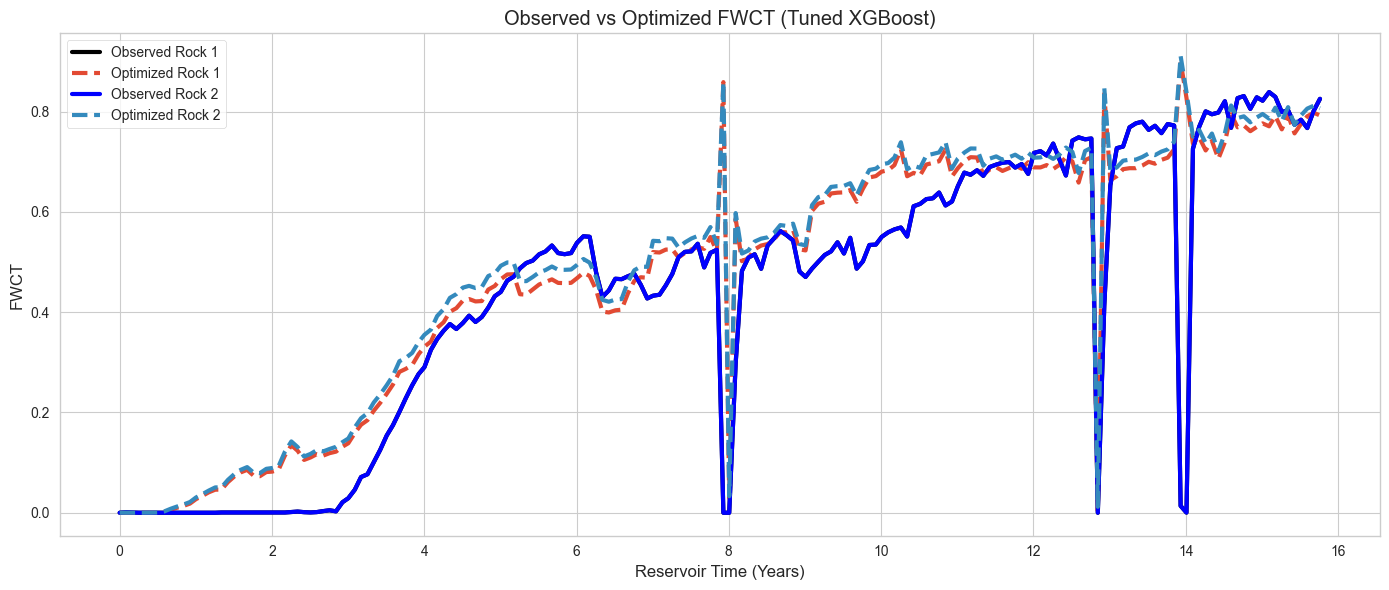

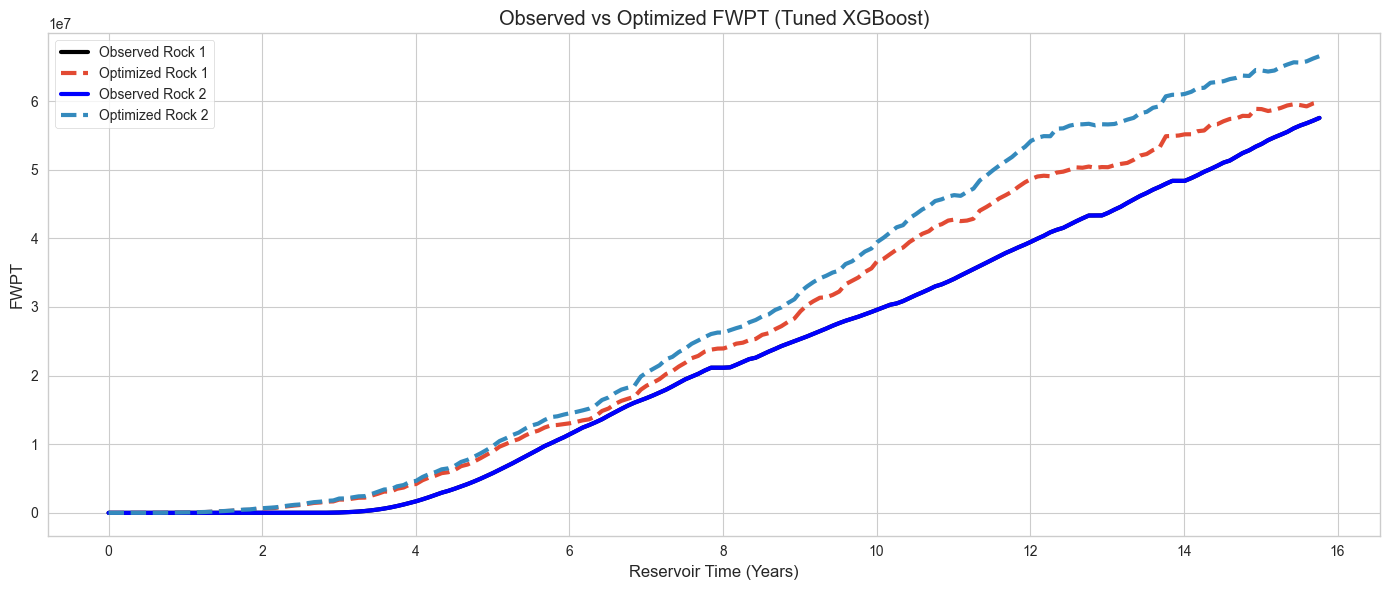

In [42]:
# ============================================================
# FWCT HISTORY MATCH
# ============================================================

plt.figure(figsize=(14,6))

# Rock 1
plt.plot(
    realizations["SIM_Year"],
    realizations["FWCT OBS"],
    color="black",
    linewidth=3,
    label="Observed Rock 1"
)

plt.plot(
    realizations["SIM_Year"],
    rock1_prediction["Predicted_FWCT"],
    "--",
    linewidth=3,
    label="Optimized Rock 1"
)

# Rock 2
plt.plot(
    realizations["SIM_Year"],
    realizations["FWCT_R2 OBS"],
    color="blue",
    linewidth=3,
    label="Observed Rock 2"
)

plt.plot(
    realizations["SIM_Year"],
    rock2_prediction["Predicted_FWCT"],
    "--",
    linewidth=3,
    label="Optimized Rock 2"
)

plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWCT")
plt.title("Observed vs Optimized FWCT (Tuned XGBoost)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# FWPT HISTORY MATCH
# ============================================================

plt.figure(figsize=(14,6))

# Rock 1
plt.plot(
    realizations["SIM_Year"],
    realizations["FWPTH OBS"],
    color="black",
    linewidth=3,
    label="Observed Rock 1"
)

plt.plot(
    realizations["SIM_Year"],
    rock1_prediction["Predicted_FWPT"],
    "--",
    linewidth=3,
    label="Optimized Rock 1"
)

# Rock 2
plt.plot(
    realizations["SIM_Year"],
    realizations["FWPTH_R2 OBS"],
    color="blue",
    linewidth=3,
    label="Observed Rock 2"
)

plt.plot(
    realizations["SIM_Year"],
    rock2_prediction["Predicted_FWPT"],
    "--",
    linewidth=3,
    label="Optimized Rock 2"
)

plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWPT")
plt.title("Observed vs Optimized FWPT (Tuned XGBoost)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# NORMALIZED OBJECTIVE FUNCTION
# ============================================================

def objective(params):

    permx, permz, relperm = params

    # --------------------------------------------------------
    # Rock 1
    # --------------------------------------------------------

    rock1 = pd.DataFrame({

        "PERMX": np.full(len(realizations), permx),
        "PERMZ": np.full(len(realizations), permz),
        "RELPERM": np.full(len(realizations), relperm),
        "Rock": np.zeros(len(realizations)),
        "Year": realizations["SIM_Year"]

    })

    # --------------------------------------------------------
    # Rock 2
    # --------------------------------------------------------

    rock2 = pd.DataFrame({

        "PERMX": np.full(len(realizations), permx),
        "PERMZ": np.full(len(realizations), permz),
        "RELPERM": np.full(len(realizations), relperm),
        "Rock": np.ones(len(realizations)),
        "Year": realizations["SIM_Year"]

    })

    # --------------------------------------------------------
    # Feature Engineering
    # --------------------------------------------------------

    rock1 = create_features(rock1)
    rock2 = create_features(rock2)

    rock1 = rock1[X.columns]
    rock2 = rock2[X.columns]

    pred1 = final_surrogate.predict(rock1)
    pred2 = final_surrogate.predict(rock2)

    # ========================================================
    # FWCT RMSE
    # ========================================================

    fwct_rmse = np.sqrt(

        np.mean((pred1[:,0] - realizations["FWCT OBS"])**2)

        +

        np.mean((pred2[:,0] - realizations["FWCT_R2 OBS"])**2)

    )

    # ========================================================
    # FWPT RMSE
    # ========================================================

    fwpt_rmse = np.sqrt(

        np.mean((pred1[:,1] - realizations["FWPTH OBS"])**2)

        +

        np.mean((pred2[:,1] - realizations["FWPTH_R2 OBS"])**2)

    )

    # ========================================================
    # Normalize
    # ========================================================

    fwct_rmse /= (

        realizations["FWCT OBS"].max()

        -

        realizations["FWCT OBS"].min()

    )

    fwpt_rmse /= (

        realizations["FWPTH OBS"].max()

        -

        realizations["FWPTH OBS"].min()

    )

    # ========================================================
    # Equal importance
    # ========================================================

    return fwct_rmse + fwpt_rmse

In [44]:
result = differential_evolution(

    objective,

    bounds,

    strategy="best1bin",

    maxiter=100,

    popsize=20,

    mutation=(0.5,1),

    recombination=0.7,

    seed=42,

    polish=True

)

best_params = result.x

In [45]:
print("="*80)
print("OPTIMIZATION FINISHED")
print("="*80)

print(result)

recommended_parameters = pd.DataFrame({

    "Parameter":[
        "PERMX",
        "PERMZ",
        "RELPERM"
    ],

    "Recommended Value":best_params

})

print()
print("="*80)
print("SURROGATE RECOMMENDATION")
print("="*80)

display(recommended_parameters)

OPTIMIZATION FINISHED
             message: Optimization terminated successfully.
             success: True
                 fun: 0.38587643059088106
                   x: [ 1.176e+00  1.169e+00  8.016e-01]
                 nit: 13
                nfev: 844
          population: [[ 1.176e+00  1.169e+00  8.016e-01]
                       [ 1.184e+00  1.127e+00  8.009e-01]
                       ...
                       [ 1.174e+00  1.136e+00  8.081e-01]
                       [ 1.168e+00  1.118e+00  8.013e-01]]
 population_energies: [ 3.859e-01  3.862e-01 ...  3.873e-01  3.866e-01]

SURROGATE RECOMMENDATION


,Parameter,Recommended Value
0,PERMX,1.176481
1,PERMZ,1.168534
2,RELPERM,0.801594


In [46]:
# ============================================================
# PREDICT USING OPTIMIZED PARAMETERS
# ============================================================

opt_permX, opt_permZ, opt_relperm = best_params

# ------------------------------------------------------------
# Rock 1
# ------------------------------------------------------------

rock1_prediction = pd.DataFrame({

    "PERMX": np.full(len(realizations), opt_permX),
    "PERMZ": np.full(len(realizations), opt_permZ),
    "RELPERM": np.full(len(realizations), opt_relperm),
    "Rock": np.zeros(len(realizations)),
    "Year": realizations["SIM_Year"]

})

rock1_prediction = create_features(rock1_prediction)

rock1_prediction = rock1_prediction[X.columns]

pred1 = final_surrogate.predict(rock1_prediction)

rock1_prediction["Predicted_FWCT"] = pred1[:,0]
rock1_prediction["Predicted_FWPT"] = pred1[:,1]

# ------------------------------------------------------------
# Rock 2
# ------------------------------------------------------------

rock2_prediction = pd.DataFrame({

    "PERMX": np.full(len(realizations), opt_permX),
    "PERMZ": np.full(len(realizations), opt_permZ),
    "RELPERM": np.full(len(realizations), opt_relperm),
    "Rock": np.ones(len(realizations)),
    "Year": realizations["SIM_Year"]

})

rock2_prediction = create_features(rock2_prediction)

rock2_prediction = rock2_prediction[X.columns]

pred2 = final_surrogate.predict(rock2_prediction)

rock2_prediction["Predicted_FWCT"] = pred2[:,0]
rock2_prediction["Predicted_FWPT"] = pred2[:,1]

print("="*80)
print("Prediction Complete")
print("="*80)

Prediction Complete


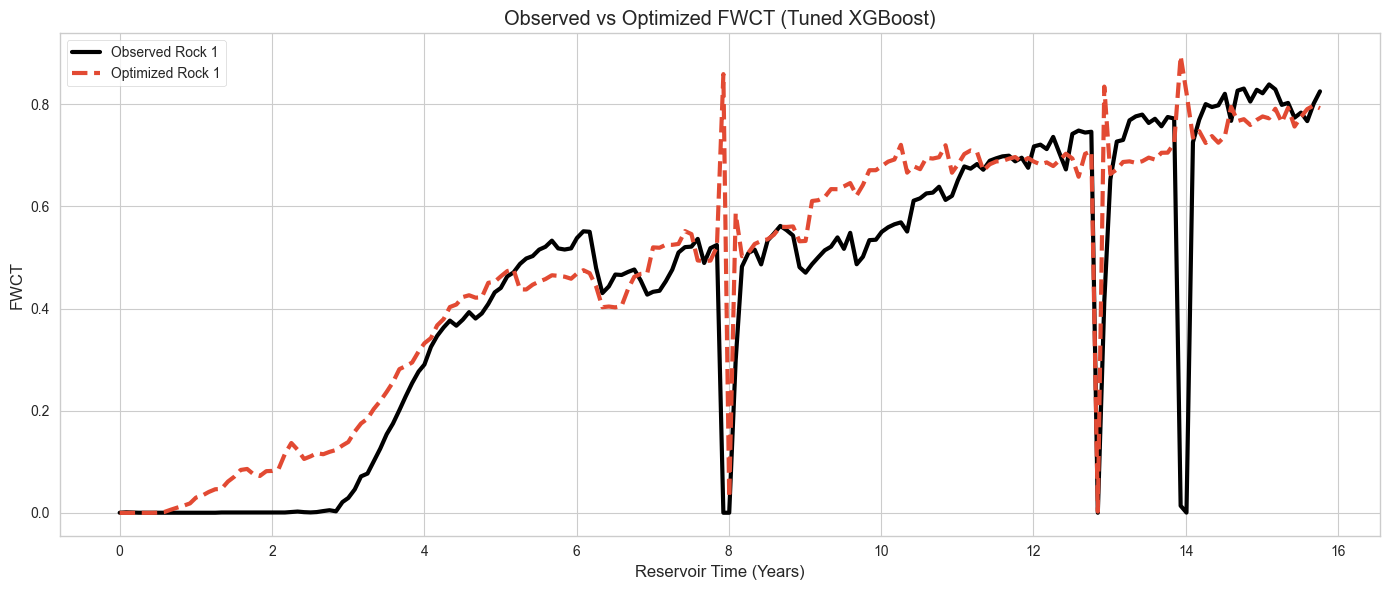

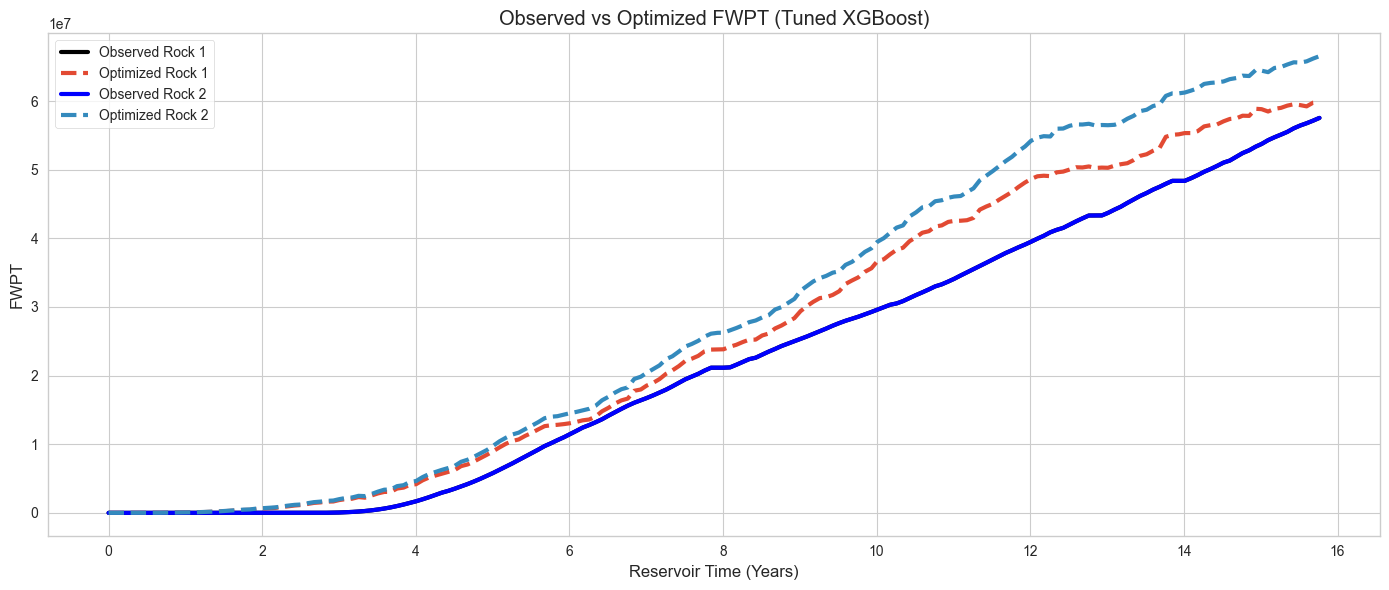

In [47]:
# ============================================================
# FWCT HISTORY MATCH
# ============================================================

plt.figure(figsize=(14,6))

# Rock 1
plt.plot(
    realizations["SIM_Year"],
    realizations["FWCT OBS"],
    color="black",
    linewidth=3,
    label="Observed Rock 1"
)

plt.plot(
    realizations["SIM_Year"],
    rock1_prediction["Predicted_FWCT"],
    "--",
    linewidth=3,
    label="Optimized Rock 1"
)


plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWCT")
plt.title("Observed vs Optimized FWCT (Tuned XGBoost)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# FWPT HISTORY MATCH
# ============================================================

plt.figure(figsize=(14,6))

# Rock 1
plt.plot(
    realizations["SIM_Year"],
    realizations["FWPTH OBS"],
    color="black",
    linewidth=3,
    label="Observed Rock 1"
)

plt.plot(
    realizations["SIM_Year"],
    rock1_prediction["Predicted_FWPT"],
    "--",
    linewidth=3,
    label="Optimized Rock 1"
)

# Rock 2
plt.plot(
    realizations["SIM_Year"],
    realizations["FWPTH_R2 OBS"],
    color="blue",
    linewidth=3,
    label="Observed Rock 2"
)

plt.plot(
    realizations["SIM_Year"],
    rock2_prediction["Predicted_FWPT"],
    "--",
    linewidth=3,
    label="Optimized Rock 2"
)

plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWPT")
plt.title("Observed vs Optimized FWPT (Tuned XGBoost)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

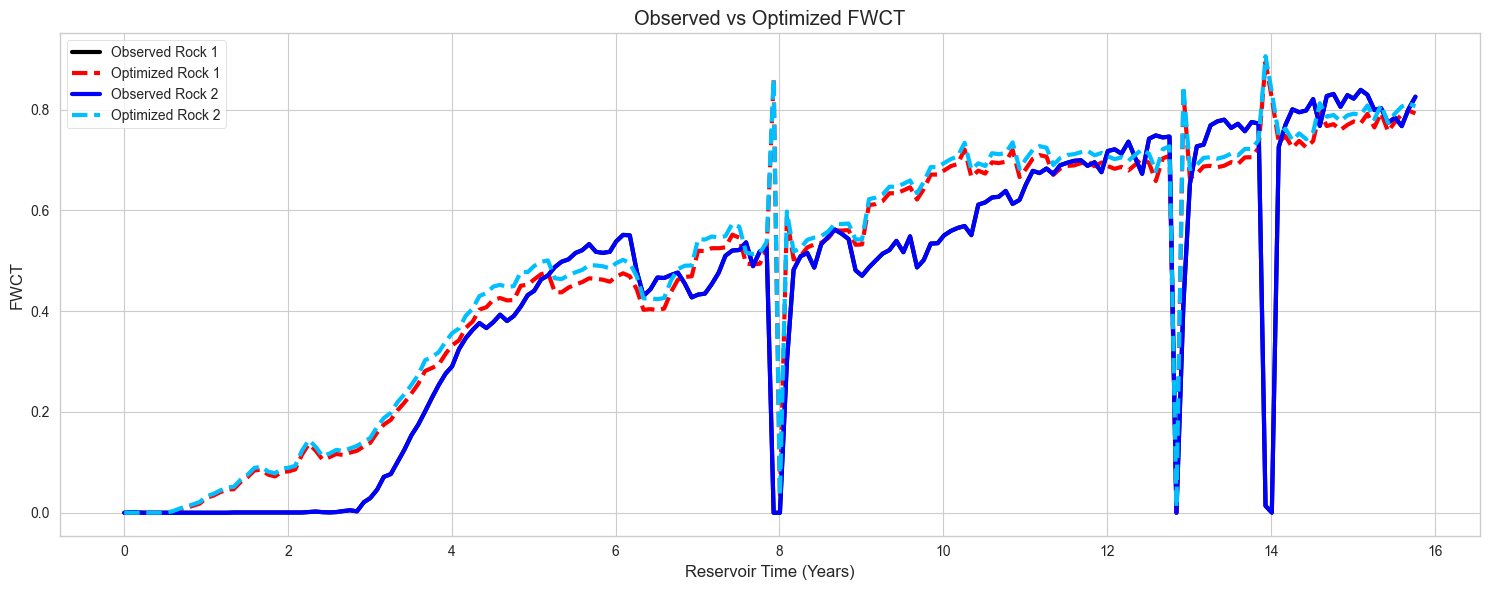

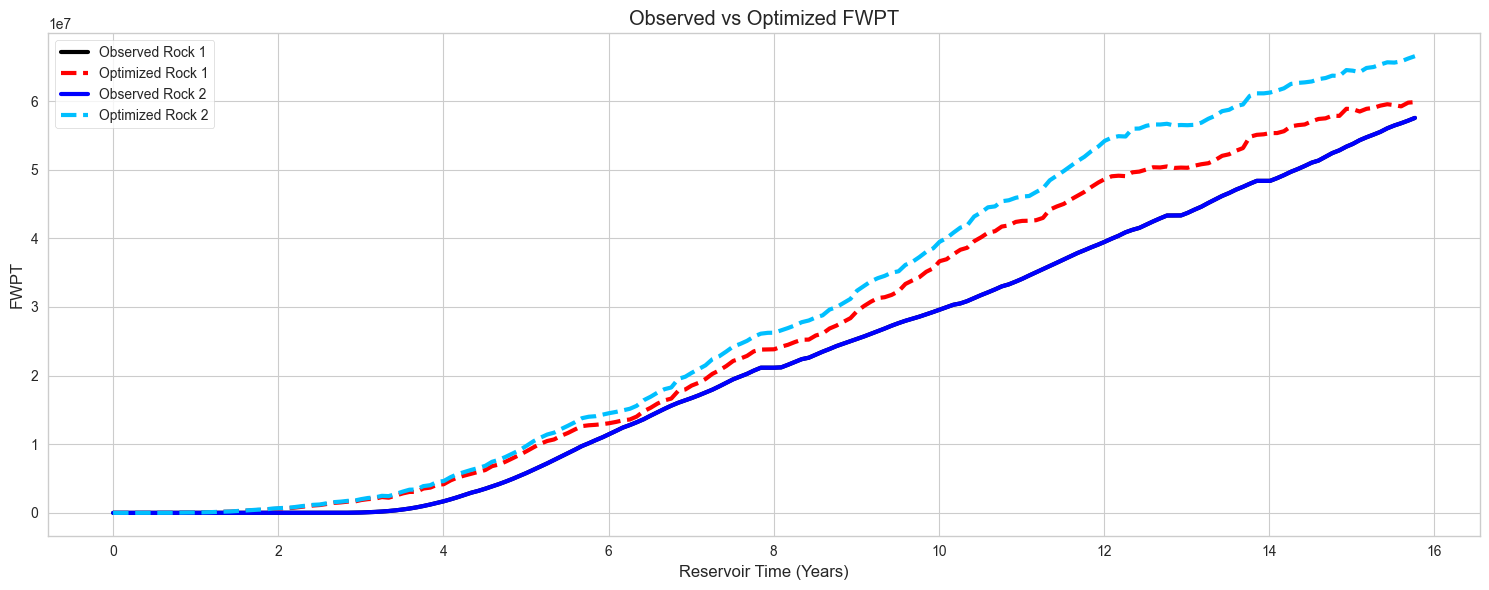

In [48]:
# =============================================================================
# FWCT HISTORY MATCH
# =============================================================================

plt.figure(figsize=(15,6))

# Rock 1
plt.plot(
    realizations["SIM_Year"],
    realizations["FWCT OBS"],
    color="black",
    linewidth=3,
    label="Observed Rock 1"
)

plt.plot(
    realizations["SIM_Year"],
    rock1_prediction["Predicted_FWCT"],
    color="red",
    linestyle="--",
    linewidth=3,
    label="Optimized Rock 1"
)

# Rock 2
plt.plot(
    realizations["SIM_Year"],
    realizations["FWCT_R2 OBS"],
    color="blue",
    linewidth=3,
    label="Observed Rock 2"
)

plt.plot(
    realizations["SIM_Year"],
    rock2_prediction["Predicted_FWCT"],
    color="deepskyblue",
    linestyle="--",
    linewidth=3,
    label="Optimized Rock 2"
)

plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWCT")
plt.title("Observed vs Optimized FWCT")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# =============================================================================
# FWPT HISTORY MATCH
# =============================================================================

plt.figure(figsize=(15,6))

# Rock 1
plt.plot(
    realizations["SIM_Year"],
    realizations["FWPTH OBS"],
    color="black",
    linewidth=3,
    label="Observed Rock 1"
)

plt.plot(
    realizations["SIM_Year"],
    rock1_prediction["Predicted_FWPT"],
    color="red",
    linestyle="--",
    linewidth=3,
    label="Optimized Rock 1"
)

# Rock 2
plt.plot(
    realizations["SIM_Year"],
    realizations["FWPTH_R2 OBS"],
    color="blue",
    linewidth=3,
    label="Observed Rock 2"
)

plt.plot(
    realizations["SIM_Year"],
    rock2_prediction["Predicted_FWPT"],
    color="deepskyblue",
    linestyle="--",
    linewidth=3,
    label="Optimized Rock 2"
)

plt.xlabel("Reservoir Time (Years)")
plt.ylabel("FWPT")
plt.title("Observed vs Optimized FWPT")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

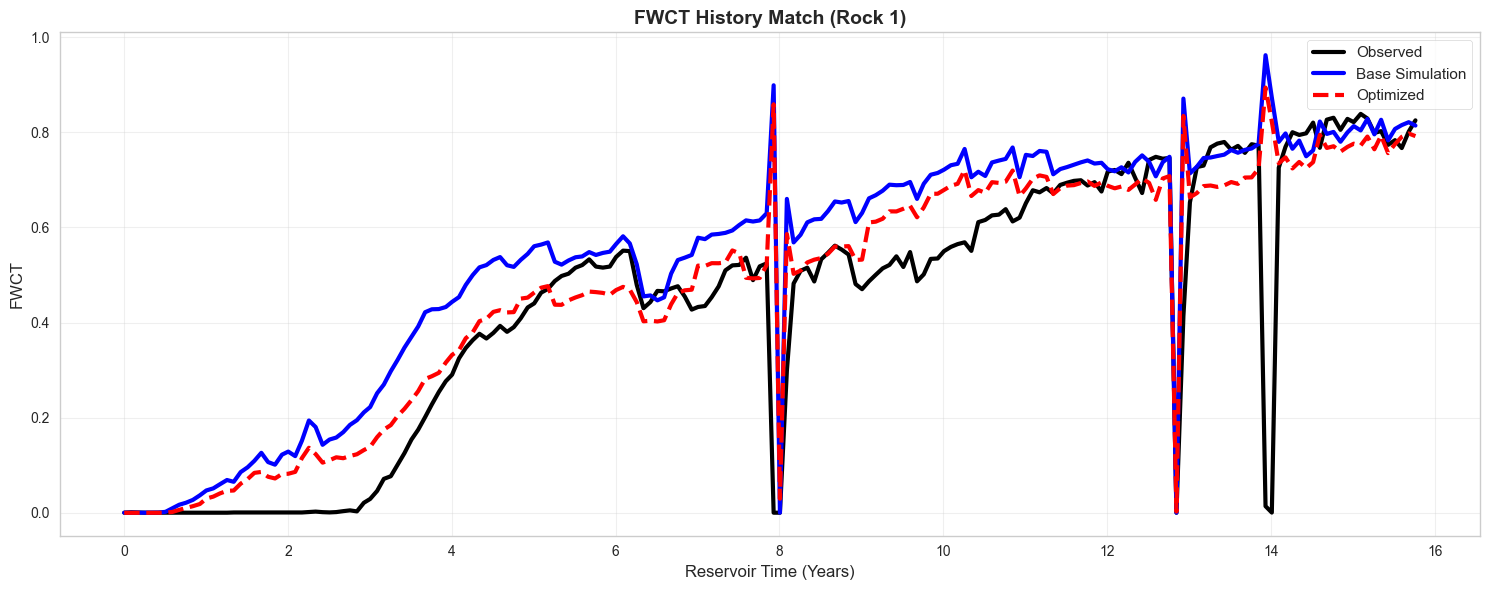

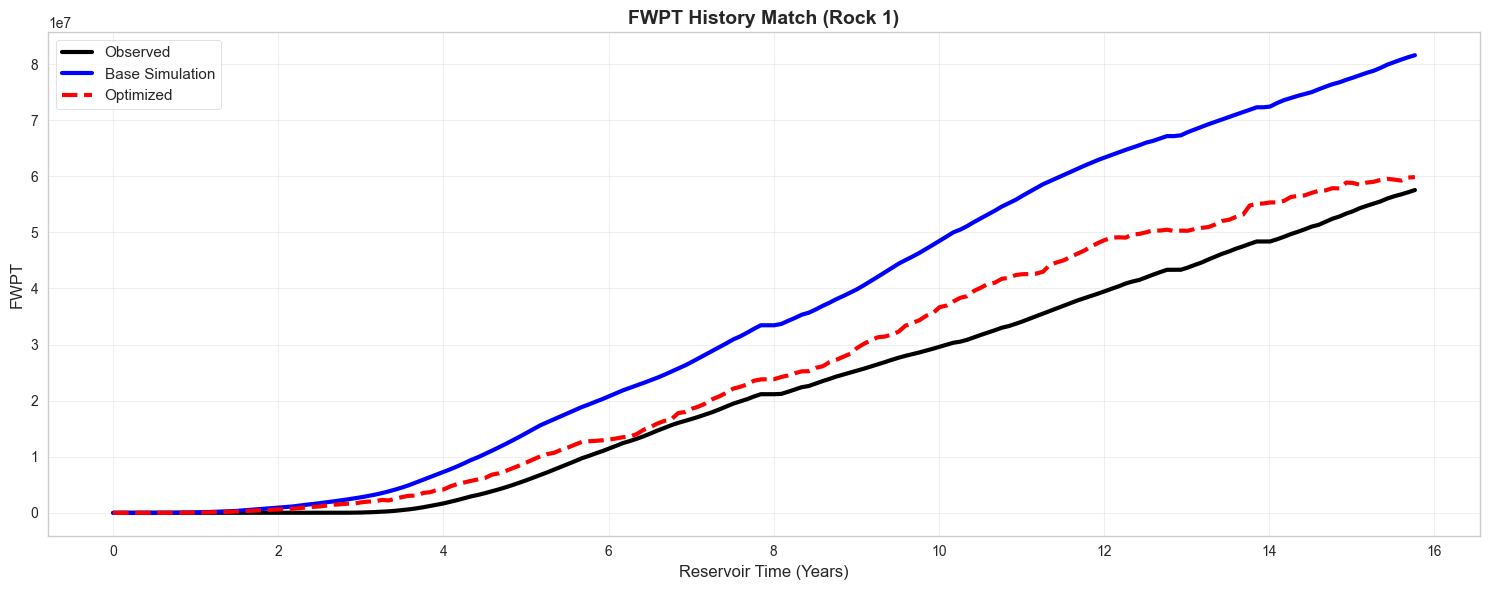

In [49]:
# =============================================================================
# FWCT HISTORY MATCH (ROCK 1)
# =============================================================================

plt.figure(figsize=(15,6))

# Observed
plt.plot(
    realizations["SIM_Year"],
    realizations["FWCT OBS"],
    color="black",
    linewidth=3,
    label="Observed"
)

# Base Simulation
plt.plot(
    realizations["SIM_Year"],
    realizations["FWCT R1R1"],
    color="blue",
    linewidth=3,
    label="Base Simulation"
)

# Optimized
plt.plot(
    realizations["SIM_Year"],
    rock1_prediction["Predicted_FWCT"],
    "--",
    color="red",
    linewidth=3,
    label="Optimized"
)

plt.xlabel("Reservoir Time (Years)", fontsize=12)
plt.ylabel("FWCT", fontsize=12)
plt.title("FWCT History Match (Rock 1)", fontsize=14, weight="bold")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

# =============================================================================
# FWPT HISTORY MATCH (ROCK 1)
# =============================================================================

plt.figure(figsize=(15,6))

# Observed
plt.plot(
    realizations["SIM_Year"],
    realizations["FWPTH OBS"],
    color="black",
    linewidth=3,
    label="Observed"
)

# Base Simulation
plt.plot(
    realizations["SIM_Year"],
    realizations["FWPT R1R1"],
    color="blue",
    linewidth=3,
    label="Base Simulation"
)

# Optimized
plt.plot(
    realizations["SIM_Year"],
    rock1_prediction["Predicted_FWPT"],
    "--",
    color="red",
    linewidth=3,
    label="Optimized"
)

plt.xlabel("Reservoir Time (Years)", fontsize=12)
plt.ylabel("FWPT", fontsize=12)
plt.title("FWPT History Match (Rock 1)", fontsize=14, weight="bold")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

In [50]:
from sklearn.metrics import mean_squared_error

fwct_rmse = np.sqrt(
    (
        mean_squared_error(realizations["FWCT OBS"], rock1_prediction["Predicted_FWCT"])
        +
        mean_squared_error(realizations["FWCT_R2 OBS"], rock2_prediction["Predicted_FWCT"])
    ) / 2
)

fwpt_rmse = np.sqrt(
    (
        mean_squared_error(realizations["FWPTH OBS"], rock1_prediction["Predicted_FWPT"])
        +
        mean_squared_error(realizations["FWPTH_R2 OBS"], rock2_prediction["Predicted_FWPT"])
    ) / 2
)

print("="*80)
print("FINAL HISTORY MATCH")
print("="*80)
print(f"FWCT RMSE : {fwct_rmse:.6f}")
print(f"FWPT RMSE : {fwpt_rmse:,.2f}")

FINAL HISTORY MATCH
FWCT RMSE : 0.132656
FWPT RMSE : 6,601,313.45


In [51]:
# ============================================================
# SAVE XGBOOST SURROGATE MODEL
# ============================================================

import os
import joblib

# Create models folder in current notebook directory
os.makedirs("models", exist_ok=True)

# Save trained surrogate
joblib.dump(
    final_surrogate,
    "models/xgboost_surrogate.pkl"
)

# Save feature order
joblib.dump(
    list(X.columns),
    "models/feature_columns.pkl"
)

print("="*80)
print("MODEL SAVED SUCCESSFULLY")
print("="*80)

print("Model saved to: models/xgboost_surrogate.pkl")
print("Feature columns saved to: models/feature_columns.pkl")

MODEL SAVED SUCCESSFULLY
Model saved to: models/xgboost_surrogate.pkl
Feature columns saved to: models/feature_columns.pkl
